In [27]:
%matplotlib widget

import os
import logging
from glob import glob
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import LogNorm
from matplotlib.backends.backend_pdf import PdfPages

from astropy.io import fits
from astropy.time import Time
from astropy.stats import sigma_clipped_stats

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy import signal

from rich.table import Table
from rich.console import Console

In [57]:
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 16,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'axes.labelpad': 10,
    'axes.linewidth': 1.2,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.fontsize': 12,
})

In [3]:
# instead of print statements, I am using logger, to classify the messages into INFO, WARNING, ERROR. 
def get_logger(log_file: str) -> logging.Logger:
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.INFO)
    logger.handlers.clear()
    
    formatter = logging.Formatter("[%(levelname)s at %(asctime)s] — %(message)s")
    
    fh = logging.FileHandler(log_file)
    fh.setFormatter(formatter)
    logger.addHandler(fh)
    
    sh = logging.StreamHandler()  # prints to notebook
    sh.setFormatter(formatter)
    logger.addHandler(sh)
    
    return logger, fh

# I will use this function to now open a log file and write all the messages to it, while also printing to the notebook.
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
logger, fh = get_logger(f"run_{timestamp}.log")
logger.info("Logger initialized successfully")

[INFO at 2026-06-11 12:59:07,221] — Logger initialized successfully


In [4]:
# I am defining a hardcoded path where all my arcs live.
pre_maintenance_dir  = "/Users/ani/local/data/soar/mask_slip/pre_maintainance/spectroscopy"
post_maintenance_dir = "/Users/ani/local/data/soar/mask_slip/post_maintainance/spectroscopy"


# Search for all downloaded FITS files recursively
def get_all_fits_files(directory: str) -> list:
    """
    Recursively searches for all FITS files in the given directory and its subdirectories.
    """
    if not os.path.exists(directory):
        logger.error(f"Directory does not exist: {directory}")
        return []
    return glob(os.path.join(directory, "**/*.fits*"), recursive=True)




# a function to filter out bad files based on some criteria, such as file size or header keywords.
# filter the arc files
def filter_fits_files(file_list):
    """
    Removes:
    - ARC files from 'triplespec' instrument
    - ARC files which are standard AEON night calibrations. they have the header key OBJECT == 'ARC'

    Keeps:
    - ARC files that are taken before and after the science exposures, which are the ones relevant for this study.
    
    Inputs:
        file_list: list of .fits file paths
    Outputs:
        good_files: list of filtered file paths
    """
    good_files = []
    
    for file in file_list:
        logger.info(f"Processing file: {file}")
        try:
            with fits.open(file) as hdul:
                header = hdul[1].header
                
                instrume = header.get("INSTRUME", "").lower()
                object_val = header.get("OBJECT", "").strip().upper()
                
                # Not considering arcs from triplespec, as they are not relevant for this study.
                if instrume == "triplespec":
                    logger.warning(f"Skipping {file} — INSTRUME: {header['INSTRUME']}")
                    continue
                
                # I am skipping arc files that are a part of the standard AEON night calibrations. They have a particular header keyword that identifies them as arcs fromt the standard AEON calibrations. For this study, we don't need them as we are mostly instrested in arcs taken before and after the science exposures. 
                if object_val == "ARC":
                    logger.warning(f"Skipping {file} — OBJECT: {header['OBJECT']}")
                    continue
                
                good_files.append(file)

        #just in case, if any file is corrupt.  
        except Exception as e:
            logger.error(f"Skipping {file} — could not read: {e}")
            continue
    
    if len(good_files) == 0:
        logger.warning("No good files found after filtering.")
    else:
        logger.info(f"Found {len(good_files)} good files after filtering.")
    return good_files


# Now I will get all the fits files from both pre and post maintenance directories, and then filter them using the above function.
pre_maintenance_files  = get_all_fits_files(pre_maintenance_dir)
post_maintenance_files = get_all_fits_files(post_maintenance_dir)


good_pre_files  = filter_fits_files(pre_maintenance_files) #arc files that are relevant for this study, taken before the maintenance
good_post_files = filter_fits_files(post_maintenance_files) #arc files that are relevant for this study, taken after the maintenance

[INFO at 2026-06-11 12:59:12,926] — Processing file: /Users/ani/local/data/soar/mask_slip/pre_maintainance/spectroscopy/triplespec/arc/SPEC_ARC_10-02-2026_0103.fits.fz
[WARNING at 2026-06-11 12:59:12,930] — Skipping /Users/ani/local/data/soar/mask_slip/pre_maintainance/spectroscopy/triplespec/arc/SPEC_ARC_10-02-2026_0103.fits.fz — INSTRUME: triplespec
[INFO at 2026-06-11 12:59:12,930] — Processing file: /Users/ani/local/data/soar/mask_slip/pre_maintainance/spectroscopy/triplespec/arc/SPEC_ARC_06-01-2026_0103.fits.fz
[WARNING at 2026-06-11 12:59:12,934] — Skipping /Users/ani/local/data/soar/mask_slip/pre_maintainance/spectroscopy/triplespec/arc/SPEC_ARC_06-01-2026_0103.fits.fz — INSTRUME: triplespec
[INFO at 2026-06-11 12:59:12,934] — Processing file: /Users/ani/local/data/soar/mask_slip/pre_maintainance/spectroscopy/triplespec/arc/SPEC_ARC_12-01-2026_0107.fits.fz
[WARNING at 2026-06-11 12:59:12,937] — Skipping /Users/ani/local/data/soar/mask_slip/pre_maintainance/spectroscopy/triplespe

In [5]:
logger.info(f'Keeping {len(good_pre_files)}/{len(pre_maintenance_files)} pre-maintenance files and {len(good_post_files)}/{len(post_maintenance_files)} post-maintenance files for analysis.')

[INFO at 2026-06-11 12:59:19,304] — Keeping 210/335 pre-maintenance files and 131/206 post-maintenance files for analysis.


In [6]:
def read_fits_file(file: str) -> tuple:
    """
    Reads a FITS file and returns a merged header and data dictionary.
    - header: merged across all HDUs (later HDUs overwrite earlier ones on duplicate keys)
    - data: dict of {hdu_index: data_array} for all HDUs
    """
    with fits.open(file) as hdul:
        header = hdul[0].header
        for i in range(1, len(hdul)):
            header.update(hdul[i].header)
        data = {i: hdul[i].data for i in range(len(hdul))}
    return header, data

    
def find_lamp_type(header: dict) -> str:

    # From the file headers, these are all the lamps available.
    lamp_mapping = {
        "LAMP_HGA": "HgAr",
        "LAMP_NE": "Ne",
        "LAMP_AR": "Ar",
        "LAMP_FE": "Fe",
        "LAMP_CU": "Cu",
        "LAMP_QUA": "Quartz",
    }

    # the heaker key hwere the value is True, is the lamp turned on. So I am considering only those lamps that are turned on, and making a tuple of their names. This step is added to identify what was the lamp that was used for the arc.
    Lamps = tuple(
        name 
        for kw, name in lamp_mapping.items() 
        if header.get(kw) in [True, "TRUE", "T"]
    )

    # if multple lamps are on, join them with a +, for example: HgAr+Ne
    lamp_str = "+".join(Lamps) if Lamps else "Unknown"

    return lamp_str

In [7]:
def build_arc_groups(good_files: list, 
                    valid_gratings: tuple = ("400_M1", "400_M2")
                    ) -> tuple[list[dict], defaultdict]:
    """
    Reads metadata from a list of arc FITS files and groups them by date, object, and grating.

    Inputs:
        good_files: list of file paths (output of filter_fits_files)
        valid_gratings: tuple of grating names to keep
    Outputs:
        metadata: list of metadata dicts, one per file
        groups: nested defaultdict grouped as groups[date][object][grating] -> list of entries
    """

    # creating a list of metadata dicts, one per file, that contains all the relevant information we need for our analysis, such as date, object, grating, lamp type.
    metadata = []
    for good_file in good_files:
        header, data = read_fits_file(good_file)
        lamp = find_lamp_type(header)
        filename = os.path.basename(good_file)
        file_path = os.path.dirname(good_file)

        metadata.append({
            "filename": filename,
            "file_path": file_path,
            "date": header['DATE'],
            "obs_datetime": header["DATE-OBS"],
            "grating": header['WAVMODE'],
            "lamps": lamp,
            "object": header.get("OBJECT", "N/A"),
        })

    # Now, with all the existing metadata, I am grouping the files in the following order: data -> object -> grating. This will give me a nested disctionary. The values will be lists of metadata entries that correspond to each combination of date, object, and grating. This grouping will allow me to easily access and analyze the arcs based on these criteria, which is important for understanding any patterns or trends in the data related to the mask slip issue.
    groups = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for entry in metadata:
        grating = entry["grating"]
        if grating in valid_gratings:
            logger.info(f"Grouping file: {entry['filename']} — Date: {entry['date']}, OBJECT: {entry['object']}, Grating: {grating}")
            groups[entry["date"]][entry["object"]][grating].append(entry)
        else:
            logger.warning(f"Skipping file with unexpected grating: {entry['filename']} — Grating: {grating}")

    return metadata, groups


# Now I will build the arc groups for both pre and post maintenance files, using the above function. This will give me a structured way to access the arcs based on their date, object, and grating, which will be useful for my analysis of the mask slip issue.
arcs_metadata_pre, groups_pre   = build_arc_groups(good_pre_files)
arcs_metadata_post, groups_post = build_arc_groups(good_post_files)

[INFO at 2026-06-11 12:59:51,248] — Grouping file: 0199_ZTF26aaffxis_17-02-2026_comp.fits.fz — Date: 2026-02-17, OBJECT: ZTF26aaffxis, Grating: 400_M1
[INFO at 2026-06-11 12:59:51,248] — Grouping file: 0260_ZTF25acfybcc_17-12-2025_comp.fits.fz — Date: 2025-12-17, OBJECT: ZTF25acfybcc, Grating: 400_M1
[INFO at 2026-06-11 12:59:51,248] — Grouping file: 0294_2023fhn-host_17-12-2025_comp.fits.fz — Date: 2025-12-17, OBJECT: 2023fhn-host, Grating: 400_M1
[INFO at 2026-06-11 12:59:51,249] — Grouping file: 0265_ZTF25acgyzdb_17-12-2025_comp.fits.fz — Date: 2025-12-17, OBJECT: ZTF25acgyzdb, Grating: 400_M1
[INFO at 2026-06-11 12:59:51,249] — Grouping file: 0198_ZTF26aaffxis_17-02-2026_comp.fits.fz — Date: 2026-02-17, OBJECT: ZTF26aaffxis, Grating: 400_M1
[INFO at 2026-06-11 12:59:51,249] — Grouping file: 0290_ZTF25achwuhy_17-12-2025_comp.fits.fz — Date: 2025-12-17, OBJECT: ZTF25achwuhy, Grating: 400_M1
[INFO at 2026-06-11 12:59:51,250] — Grouping file: 0295_2023fhn-host_17-12-2025_comp.fits.fz —

In [16]:
from rich.table import Table
from rich.console import Console

table = Table(title="Arc Group Summary")
table.add_column("Maintenance Status", style="cyan")
table.add_column("Number of Groups",   style="magenta", justify="right")
table.add_column("Median Files/Group", style="green",   justify="right")

for groups, label in [(groups_pre, "Pre-Maintenance"), (groups_post, "Post-Maintenance")]:
    group_sizes = []
    for date in groups:
        for obj in groups[date]:
            for grating in groups[date][obj]:
                group_sizes.append(len(groups[date][obj][grating]))

    n_groups     = len(group_sizes)
    median_files = np.median(group_sizes) if group_sizes else 0

    table.add_row(label, str(n_groups), f"{median_files:.1f}")

Console().print(table)

                      Arc Group Summary                       
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Maintenance Status ┃ Number of Groups ┃ Median Files/Group ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ Pre-Maintenance    │               78 │                1.5 │
│ Post-Maintenance   │               39 │                2.0 │
└────────────────────┴──────────────────┴────────────────────┘

In [19]:
def build_grouped_arc_files(groups: defaultdict, standard_stars: set) -> list[dict]:
    """
    Flattens a nested arc group defaultdict into a sorted, enriched list of valid arc groups.

    Removes:
    - Groups where the object is a known standard star
    - Groups with fewer than 2 arc files

    Inputs:
        groups: nested defaultdict grouped as groups[date][object][grating] -> list of entries
        standard_stars: set of object names to exclude (e.g. known spectrophotometric standards)
    Outputs:
        grouped_arc_files: flat list of dicts, one per valid group, with sorted filenames,
                           file paths, datetimes, and delta times
    """
    grouped_arc_files = []

    for date in groups.keys():
        for obj in groups[date].keys():
            for grating in groups[date][obj].keys():
                arc_files = groups[date][obj][grating]
                count = len(arc_files)
                sorted_files = sorted(arc_files, key=lambda x: x["obs_datetime"])

                if "Calibration-Star" in arc_files:
                    logger.warning(f"Skipping Calibration-Star group — Date: {date}, OBJECT: {obj}, Grating: {grating}")
                    continue

                if obj in standard_stars:
                    logger.warning(f"Skipping standard star — Date: {date}, OBJECT: {obj}, Grating: {grating}")
                    continue

                if count < 2:
                    logger.warning(f"Not enough files to analyze — Date: {date}, OBJECT: {obj}, Grating: {grating}, Count: {count}")
                    continue

                previous_file_datetime = None
                logger.info("-" * 50)
                logger.info(f"Date: {date}, OBJECT: {obj}, Grating: {grating}, Count: {count}")

                delta_file_datetime_seconds_all = []
                for arc_file in sorted_files:
                    filename = arc_file["filename"]
                    current_file_datetime = Time(arc_file["obs_datetime"]).to_datetime()

                    if previous_file_datetime is None:
                        delta_file_datetime_seconds = 0
                    else:
                        delta_file_datetime_seconds = (current_file_datetime - previous_file_datetime).total_seconds()

                    logger.info(f"  - {filename}, dt = {delta_file_datetime_seconds} seconds")
                    delta_file_datetime_seconds_all.append(delta_file_datetime_seconds)

                    previous_file_datetime = current_file_datetime

                grouped_arc_files.append({
                    "date": date,
                    "object": obj,
                    "grating": grating,
                    "lamps": arc_files[0]["lamps"],
                    "arc_files": [arc_file["filename"] for arc_file in sorted_files],
                    "file_paths": [arc_file["file_path"] for arc_file in sorted_files],
                    "datetimes": [arc_file["obs_datetime"] for arc_file in sorted_files],
                    "delta_time_seconds": delta_file_datetime_seconds_all,
                })

    return grouped_arc_files


# ---- Standard stars to exclude from analysis ----
standard_stars = {"HR9087", "HR1996", "LTT3218", "HD49798"}
# -------------------------------------------------

grouped_arc_files_pre  = build_grouped_arc_files(groups_pre,  standard_stars)
grouped_arc_files_post = build_grouped_arc_files(groups_post, standard_stars)

[INFO at 2026-06-11 13:31:00,333] — --------------------------------------------------
[INFO at 2026-06-11 13:31:00,335] — Date: 2026-02-17, OBJECT: ZTF26aaffxis, Grating: 400_M1, Count: 6
[INFO at 2026-06-11 13:31:00,335] —   - 0197_ZTF26aaffxis_17-02-2026_comp.fits.fz, dt = 0 seconds
[INFO at 2026-06-11 13:31:00,336] —   - 0198_ZTF26aaffxis_17-02-2026_comp.fits.fz, dt = 14.866 seconds
[INFO at 2026-06-11 13:31:00,341] —   - 0199_ZTF26aaffxis_17-02-2026_comp.fits.fz, dt = 14.848 seconds
[INFO at 2026-06-11 13:31:00,342] —   - 0203_ZTF26aaffxis_17-02-2026_comp.fits.fz, dt = 3211.812 seconds
[INFO at 2026-06-11 13:31:00,343] —   - 0204_ZTF26aaffxis_17-02-2026_comp.fits.fz, dt = 14.944 seconds
[INFO at 2026-06-11 13:31:00,346] —   - 0205_ZTF26aaffxis_17-02-2026_comp.fits.fz, dt = 14.857 seconds
[WARNING at 2026-06-11 13:31:00,347] — Skipping standard star — Date: 2026-02-17, OBJECT: HD49798, Grating: 400_M1
[INFO at 2026-06-11 13:31:00,347] — ---------------------------------------------

In [23]:
table = Table(title="Arc Group Summary")
table.add_column("Maintenance Status", style="cyan")
table.add_column("Number of Groups",   style="magenta", justify="right")
table.add_column("Median Files/Group", style="green",   justify="right")

for grouped_arc_files, label in [(grouped_arc_files_pre, "Pre-Maintenance"), (grouped_arc_files_post, "Post-Maintenance")]:
    group_sizes  = [len(group["arc_files"]) for group in grouped_arc_files]
    n_groups     = len(group_sizes)
    median_files = np.median(group_sizes) if group_sizes else 0

    table.add_row(label, str(n_groups), f"{median_files:.1f}")

Console().print(table)

                      Arc Group Summary                       
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Maintenance Status ┃ Number of Groups ┃ Median Files/Group ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ Pre-Maintenance    │               35 │                3.0 │
│ Post-Maintenance   │               15 │                6.0 │
└────────────────────┴──────────────────┴────────────────────┘

In [25]:
# for group in grouped_arc_files_pre:
#     if len(group["arc_files"]) >= 3:
#         print(group["date"], group["object"], group["grating"])
#         for f, dt in zip(group["arc_files"], group["delta_time_seconds"]):
#             print(f"  {f}  dt={dt:.0f}s")
#         print()

In [28]:
def calculate_cross_correlation_shifts(grouped_arc_files: list[dict]) -> None:
    """
    Calculates cross-correlation shifts for all arc files in each group,
    relative to the first file in the group.

    Updates each group dict in-place with:
        - dx: list of integer pixel shifts relative to file 0
        - confidence_scores: list of normalized cross-correlation scores (0.0 to 1.0)

    Inputs:
        grouped_arc_files: list of group dicts (output of build_grouped_arc_files)
    Outputs:
        None — modifies grouped_arc_files in-place
    """
    logger.info(f"Starting cross-correlation shift calculation for {len(grouped_arc_files)} groups...")

    for group in grouped_arc_files:
        files = [
            os.path.join(group["file_paths"][i], group["arc_files"][i])
            for i in range(len(group["arc_files"]))
        ]

        if not files:
            group["dx"] = []
            group["confidence_scores"] = []
            continue

        # Establish the reference spectrum from file 0
        reference_file = files[0]
        try:
            _, data = read_fits_file(reference_file)
            one_d_spec_reference = np.sum(data[1], axis=0).astype(np.float64)
        except Exception as e:
            logger.error(f"Failed to read reference file {reference_file}: {e}")
            group["dx"] = [np.nan] * len(files)
            group["confidence_scores"] = [np.nan] * len(files)
            continue

        relative_shifts  = []
        confidence_scores = []

        for current_file in files:
            try:
                _, data = read_fits_file(current_file)
                current_spectrum = np.sum(data[1], axis=0).astype(np.float64)

                # Cross-correlate against the reference spectrum
                correlation = signal.correlate(current_spectrum, one_d_spec_reference, mode='full')
                lags        = signal.correlation_lags(len(current_spectrum), len(one_d_spec_reference), mode='full')

                best_idx   = np.argmax(correlation)
                shift_pixels = lags[best_idx]

                # Normalized confidence score (0.0 to 1.0)
                norm_factor      = np.sqrt(np.sum(current_spectrum**2) * np.sum(one_d_spec_reference**2))
                confidence_score = correlation[best_idx] / norm_factor

                relative_shifts.append(shift_pixels)
                confidence_scores.append(confidence_score)

                logger.info(f"  {os.path.basename(current_file)} — Shift: {shift_pixels} px | Confidence: {confidence_score:.4f}")

            except Exception as e:
                logger.error(f"Failed to process file {current_file}: {e}")
                relative_shifts.append(np.nan)
                confidence_scores.append(np.nan)

        group["dx"] = relative_shifts
        group["confidence_scores"] = confidence_scores

        logger.info(
            f"Processed Date: {group['date']} | Obj: {group['object']} | Grating: {group['grating']} "
            f"— Shifts: {relative_shifts}"
        )

    logger.info("Finished calculating all dx shifts.")


calculate_cross_correlation_shifts(grouped_arc_files_pre)
calculate_cross_correlation_shifts(grouped_arc_files_post)

[INFO at 2026-06-11 13:46:55,605] — Starting cross-correlation shift calculation for 35 groups...
[INFO at 2026-06-11 13:46:55,675] —   0197_ZTF26aaffxis_17-02-2026_comp.fits.fz — Shift: 0 px | Confidence: 1.0000
[INFO at 2026-06-11 13:46:55,710] —   0198_ZTF26aaffxis_17-02-2026_comp.fits.fz — Shift: 0 px | Confidence: 1.0000
[INFO at 2026-06-11 13:46:55,747] —   0199_ZTF26aaffxis_17-02-2026_comp.fits.fz — Shift: 0 px | Confidence: 0.9907
[INFO at 2026-06-11 13:46:55,783] —   0203_ZTF26aaffxis_17-02-2026_comp.fits.fz — Shift: -9 px | Confidence: 0.4684
[INFO at 2026-06-11 13:46:55,820] —   0204_ZTF26aaffxis_17-02-2026_comp.fits.fz — Shift: -9 px | Confidence: 0.6101
[INFO at 2026-06-11 13:46:55,856] —   0205_ZTF26aaffxis_17-02-2026_comp.fits.fz — Shift: -9 px | Confidence: 0.7746
[INFO at 2026-06-11 13:46:55,856] — Processed Date: 2026-02-17 | Obj: ZTF26aaffxis | Grating: 400_M1 — Shifts: [np.int64(0), np.int64(0), np.int64(0), np.int64(-9), np.int64(-9), np.int64(-9)]
[INFO at 2026-06

In [94]:
from rich.table import Table
from rich.console import Console

def print_dx_matrix(grouped_arc_files: list[dict], title: str) -> None:
    """
    Prints the dx shifts for all groups as a matrix, one group per row.
    Non-zero shifts are highlighted in red.

    Inputs:
        grouped_arc_files: list of group dicts (output of calculate_cross_correlation_shifts)
        title: table title (e.g. 'Pre-Maintenance dx Matrix')
    """
    max_files = max(len(group["dx"]) for group in grouped_arc_files)

    table = Table(title=title)
    table.add_column("Date",    style="cyan",    no_wrap=True)
    table.add_column("Object",  style="magenta", no_wrap=True)
    table.add_column("Grating", style="green",   no_wrap=True)

    for i in range(max_files):
        table.add_column(f"dx[{i}]", justify="right")

    for group in grouped_arc_files:
        dx = group["dx"]
        row = [
            group["date"],
            group["object"],
            group["grating"],
        ]
        for i in range(max_files):
            if i < len(dx):
                val = dx[i]
                if np.isnan(val):
                    row.append("NaN")
                elif val != 0:
                    row.append(f"[red]{val:.1f}[/red]")
                else:
                    row.append(f"{val:.1f}")
            else:
                row.append("-")

        table.add_row(*row)

    Console().print(table)

In [93]:
def print_dx_matrix_latex(grouped_arc_files: list[dict], title: str, label: str) -> str:
    """
    Generates a LaTeX table of dx shifts for all groups.
    Each cell shows dx (dt, conf).
    - Non-zero, high confidence shifts: red highlight
    - Non-zero, low confidence shifts:  gray highlight
    Requires: \\usepackage{xcolor}, \\usepackage{booktabs}, \\usepackage{pdflscape}

    Inputs:
        grouped_arc_files: list of group dicts (output of calculate_cross_correlation_shifts)
        title: LaTeX table caption
        label: LaTeX table label (for \\ref{})
    Outputs:
        latex_str: LaTeX table as a string
    """
    CONF_THRESHOLD = 0.8

    max_files = max(len(group["dx"]) for group in grouped_arc_files)
    col_spec  = "lll" + "r" * max_files

    lines = []
    lines.append(r"\begin{landscape}")
    lines.append(r"{\tiny")
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"  \centering")
    lines.append(f"  \\caption{{{title}}}")
    lines.append(f"  \\label{{{label}}}")
    lines.append(f"  \\begin{{tabular}}{{{col_spec}}}")
    lines.append(r"    \toprule")

    # Header row
    header = ["Date", "Object", "Grating"] + [f"dx[{i}]" for i in range(max_files)]
    lines.append("    " + " & ".join(header) + r" \\")
    lines.append(r"    \midrule")

    # Data rows
    for group in grouped_arc_files:
        dx   = group["dx"]
        conf = group["confidence_scores"]
        dt   = group["delta_time_seconds"]

        row = [
            group["date"],
            group["object"].replace("_", r"\_"),
            group["grating"].replace("_", r"\_"),
        ]

        for i in range(max_files):
            if i < len(dx):
                dx_val   = dx[i]
                conf_val = conf[i]
                dt_val   = dt[i]

                if np.isnan(dx_val):
                    cell = "NaN"
                else:
                    cell = f"{dx_val:.0f} (dt={dt_val:.0f}s, c={conf_val:.2f})"
                    if dx_val != 0 and conf_val >= CONF_THRESHOLD:
                        cell = r"\cellcolor{red!30}" + cell
                    elif dx_val != 0 and conf_val < CONF_THRESHOLD:
                        cell = r"\cellcolor{gray!20}" + cell
            else:
                cell = "--"

            row.append(cell)

        lines.append("    " + " & ".join(row) + r" \\")

    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")
    lines.append(r"}")
    lines.append(r"\end{landscape}")

    return "\n".join(lines)


latex_pre  = print_dx_matrix_latex(grouped_arc_files_pre,  "Arc Mask Slip dx Matrix — Pre-Maintenance",  "tab:dx_matrix_pre")
latex_post = print_dx_matrix_latex(grouped_arc_files_post, "Arc Mask Slip dx Matrix — Post-Maintenance", "tab:dx_matrix_post")

print(latex_pre)
print()
print(latex_post)

\begin{landscape}
{\tiny
\begin{table}[htbp]
  \centering
  \caption{Arc Mask Slip dx Matrix — Pre-Maintenance}
  \label{tab:dx_matrix_pre}
  \begin{tabular}{lllrrrrrrrrr}
    \toprule
    Date & Object & Grating & dx[0] & dx[1] & dx[2] & dx[3] & dx[4] & dx[5] & dx[6] & dx[7] & dx[8] \\
    \midrule
    2026-02-17 & ZTF26aaffxis & 400\_M1 & 0 (dt=0s, c=1.00) & 0 (dt=15s, c=1.00) & 0 (dt=15s, c=0.99) & \cellcolor{gray!20}-9 (dt=3212s, c=0.47) & \cellcolor{gray!20}-9 (dt=15s, c=0.61) & \cellcolor{gray!20}-9 (dt=15s, c=0.77) & -- & -- & -- \\
    2025-12-17 & ZTF25acfybcc & 400\_M1 & 0 (dt=0s, c=1.00) & 0 (dt=15s, c=0.99) & 0 (dt=15s, c=0.93) & -- & -- & -- & -- & -- & -- \\
    2025-12-17 & 2023fhn-host & 400\_M1 & 0 (dt=0s, c=1.00) & 0 (dt=15s, c=1.00) & 0 (dt=15s, c=1.00) & -- & -- & -- & -- & -- & -- \\
    2025-12-17 & ZTF25acgyzdb & 400\_M1 & 0 (dt=0s, c=1.00) & 0 (dt=15s, c=0.99) & 0 (dt=15s, c=0.97) & -- & -- & -- & -- & -- & -- \\
    2025-12-17 & ZTF25achwuhy & 400\_M1 & 0 (dt=0

In [95]:
print_dx_matrix(grouped_arc_files_pre,  "Pre-Maintenance dx Matrix")

                                            Pre-Maintenance dx Matrix                                             
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃ Date       ┃ Object          ┃ Grating ┃ dx[0] ┃ dx[1] ┃ dx[2] ┃ dx[3] ┃ dx[4] ┃ dx[5] ┃ dx[6] ┃ dx[7] ┃ dx[8] ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 2026-02-17 │ ZTF26aaffxis    │ 400_M1  │   0.0 │   0.0 │   0.0 │  -9.0 │  -9.0 │  -9.0 │     - │     - │     - │
│ 2025-12-17 │ ZTF25acfybcc    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-17 │ 2023fhn-host    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-17 │ ZTF25acgyzdb    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-17 │ ZTF25achwuhy    │ 400_M1  │   0.0 │   0.0 │   0.0 │   3.0 │   3.0 │   3.0 │     - │     - │     - │
│ 2025-12-17 │ ZTF25acgopcs    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-17 │ ZTF25acgwohc    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-01-08 │ 2025ahoe        │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-03 │ ZTF25acbjqvq    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-03 │ ZTF25abxvhmk    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-03 │ ZTF18acecugr    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-03 │ ZTF25abwkieo    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-30 │ ZTF25aciemqo    │ 400_M1  │   0.0 │  -6.0 │  -6.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-30 │ ZTF25achxgfw    │ 400_M1  │   0.0 │   0.0 │   0.0 │   8.0 │   8.0 │   8.0 │     - │     - │     - │
│ 2025-12-30 │ ZTF18aafhmpq    │ 400_M1  │   0.0 │   0.0 │   0.0 │   1.0 │   1.0 │   1.0 │     - │     - │     - │
│ 2025-12-30 │ ZTF25acjfaoq    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-08 │ Fortinbras-host │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-01-19 │ ZTF26aaayaic    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-01-19 │ ZTF26aabpzxh    │ 400_M1  │   0.0 │   0.0 │   0.0 │   4.0 │   4.0 │   4.0 │     - │     - │     - │
│ 2025-12-12 │ ZTF25accmopr    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-12 │ ZTF25acfyeke    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-12 │ ZTF25acfyjrh    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-01-03 │ ZTF18acecugr    │ 400_M2  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-01-03 │ ZTF18acecugr    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-01-07 │ ZTF25acgorke    │ 400_M1  │   0.0 │   0.0 │   0.0 │   1.0 │   1.0 │   1.0 │     - │     - │     - │
│ 2026-01-04 │ ZTF25achogfs    │ 400_M1  │   0.0 │   0.0 │   0.0 │   1.0 │   1.0 │   1.0 │     - │     - │     - │
│ 2026-01-04 │ ZTF25acjbekr    │ 400_M1  │   0.0 │   0.0 │   0.0 │   6.0 │   6.0 │   6.0 │     - │     - │     - │
│ 2026-02-11 │ ZTF26aaecpsp    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-02-11 │ ZTF26aaffxis    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-02-11 │ ZTF26aaffpvx    │ 400_M2  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-02-11 │ ZTF26aaffpvx    │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │

In [49]:
print_dx_matrix(grouped_arc_files_post, "Post-Maintenance dx Matrix")

                                            Post-Maintenance dx Matrix                                             
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Date       ┃ Object            ┃ Grating ┃ dx[0] ┃ dx[1] ┃ dx[2] ┃ dx[3] ┃ dx[4] ┃ dx[5] ┃ dx[6] ┃ dx[7] ┃ dx[… ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2026-05-09 │ ZTF26aauuvgc      │ 400_M1  │   0.0 │   0.0 │   0.0 │   5.0 │   5.0 │   5.0 │     - │     - │    - │
│ 2026-05-09 │ ZTF26aaudbym      │ 400_M1  │   0.0 │   0.0 │   0.0 │   2.0 │   2.0 │   2.0 │     - │     - │    - │
│ 2026-05-08 │ ZTF26aaudbym      │ 400_M1  │   0.0 │   0.0 │   0.0 │   3.0 │   3.0 │   3.0 │     - │     - │    - │
│ 2026-05-20 │ ASKAP14517689     │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │    - │
│ 2026-05-26 │ ZTF26aaxhvtq      │ 400_M1  │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │     - │    - │
│ 2026-05-12 │ ZTF26aauxgoe      │ 400_M2  │   0.0 │   0.0 │   0.0 │   3.0 │   3.0 │   0.0 │     - │     - │    - │
│ 2026-05-12 │ ZTF26aauuvgc      │ 400_M2  │   0.0 │   0.0 │   0.0 │   7.0 │   7.0 │   7.0 │     - │     - │    - │
│ 2026-04-22 │ 43977565387744629 │ 400_M1  │   0.0 │   0.0 │   0.0 │   7.0 │   7.0 │   7.0 │     - │     - │    - │
│ 2026-04-22 │ ZTF26aaonmha      │ 400_M1  │   0.0 │   0.0 │   0.0 │   0.0 │   0.0 │   0.0 │   6.0 │   6.0 │  6.0 │
│ 2026-04-22 │ ZTF26aanefqu      │ 400_M1  │   0.0 │   0.0 │   0.0 │   7.0 │   7.0 │   7.0 │     - │     - │    - │
│ 2026-05-16 │ ZTF26aauvalc      │ 400_M1  │   0.0 │   0.0 │   0.0 │   9.0 │   9.0 │   9.0 │     - │     - │    - │
│ 2026-04-30 │ ZTF26aasnlpp      │ 400_M1  │   0.0 │   0.0 │   0.0 │ 802.0 │   4.0 │   4.0 │     - │     - │    - │
│ 2026-04-30 │ ZTF26aaonmha      │ 400_M1  │   0.0 │   0.0 │   0.0 │   7.0 │   7.0 │   7.0 │     - │     - │    - │
│ 2026-04-26 │ ZTF26aapoypz      │ 400_M1  │   0.0 │   0.0 │   0.0 │   7.0 │   7.0 │   7.0 │     - │     - │    - │
│ 2026-04-26 │ ZTF26aasmxig      │ 400_M1  │   0.0 │   0.0 │   0.0 │   7.0 │   7.0 │   7.0 │     - │     - │    - │
└────────────┴───────────────────┴─────────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴──────┘

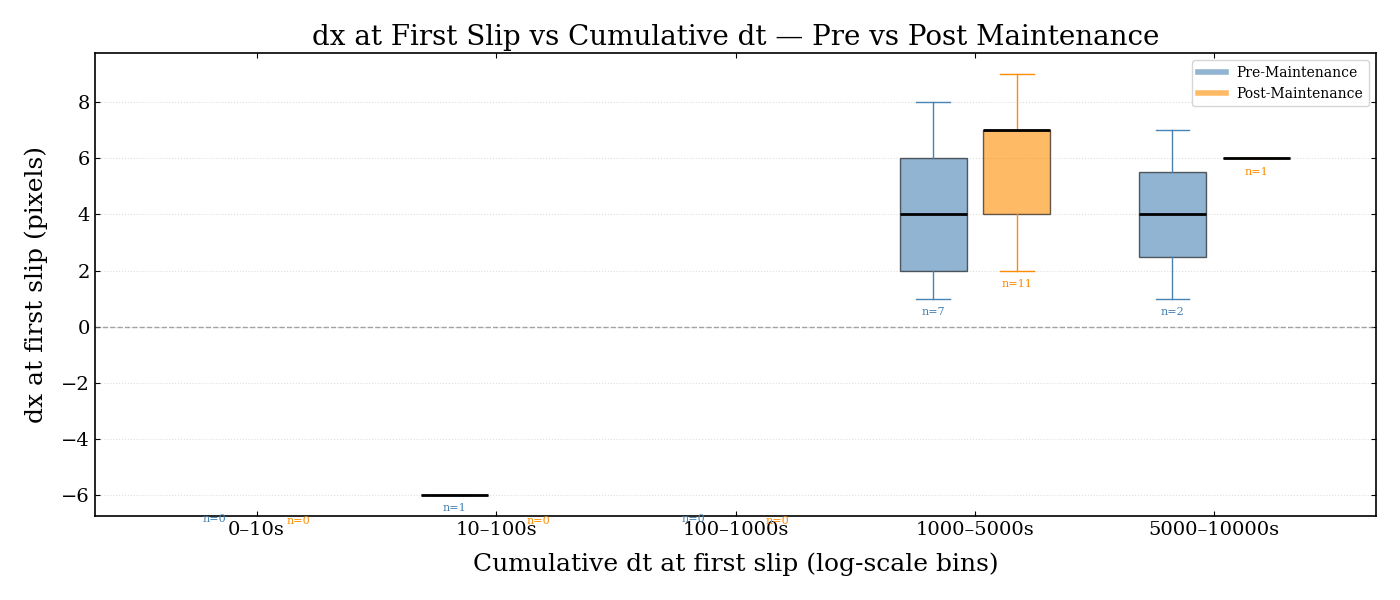

In [66]:
def plot_dx_vs_dt_boxplot(grouped_arc_files_pre: list[dict], grouped_arc_files_post: list[dict]) -> None:
    """
    Plots dx at first slip vs cumulative dt at first slip, binned in log scale.

    Bins: 0-10s, 10-100s, 100-1000s, 1000-5000s, 5000-10000s
    - First slip defined as first file where dx != 0 and |dx| < 20 and conf >= 0.8
    - Pre and post shown side by side within each bin
    """
    CONF_THRESHOLD = 0.8
    DX_MASK        = 20
    BIN_EDGES      = [0, 10, 100, 1000, 5000, 10000]
    BIN_LABELS     = ["0–10s", "10–100s", "100–1000s", "1000–5000s", "5000–10000s"]

    def extract_first_slip(grouped_arc_files):
        """Returns list of (cumulative_dt, dx) at first slip per group."""
        first_slips = []
        for g in grouped_arc_files:
            cumulative_dt = np.cumsum(g["delta_time_seconds"])
            for i in range(1, len(g["dx"])):  # skip file 0 (reference)
                dx   = g["dx"][i]
                conf = g["confidence_scores"][i]
                if np.isnan(dx):
                    continue
                if abs(dx) >= DX_MASK:
                    continue
                if conf < CONF_THRESHOLD:
                    continue
                if dx != 0:
                    first_slips.append((cumulative_dt[i], dx))
                    break  # only first slip per group
        return first_slips

    slips_pre  = extract_first_slip(grouped_arc_files_pre)
    slips_post = extract_first_slip(grouped_arc_files_post)

    def bin_slips(slips):
        """Bin slips by cumulative dt into log-scale bins."""
        binned = {label: [] for label in BIN_LABELS}
        for dt, dx in slips:
            for i in range(len(BIN_EDGES) - 1):
                if BIN_EDGES[i] <= dt < BIN_EDGES[i + 1]:
                    binned[BIN_LABELS[i]].append(dx)
                    break
        return binned

    binned_pre  = bin_slips(slips_pre)
    binned_post = bin_slips(slips_post)

    fig, ax = plt.subplots(figsize=(14, 6))

    x      = np.arange(len(BIN_LABELS))
    width  = 0.35
    offset = width / 2

    for binned, color, label, sign in [
        (binned_pre,  "steelblue",  "Pre-Maintenance",  -1),
        (binned_post, "darkorange", "Post-Maintenance",  1),
    ]:
        positions = x + sign * offset
        data      = [binned[bl] for bl in BIN_LABELS]

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=width * 0.8,
            patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.6),
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(color=color),
            capprops=dict(color=color),
            flierprops=dict(marker="o", color=color, alpha=0.5),
        )

        # Annotate with n per bin
        for pos, d in zip(positions, data):
            ax.text(pos, ax.get_ylim()[0] if len(d) == 0 else min(d) - 0.3,
                    f"n={len(d)}", ha="center", va="top", fontsize=8, color=color)

        # Legend proxy
        ax.plot([], [], color=color, linewidth=4, alpha=0.6, label=label)

    ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(BIN_LABELS)
    ax.set_xlabel("Cumulative dt at first slip (log-scale bins)")
    ax.set_ylabel("dx at first slip (pixels)")
    ax.set_title("dx at First Slip vs Cumulative dt — Pre vs Post Maintenance")
    ax.legend(fontsize=10)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    plt.tight_layout()
    plt.show()


plot_dx_vs_dt_boxplot(grouped_arc_files_pre, grouped_arc_files_post)

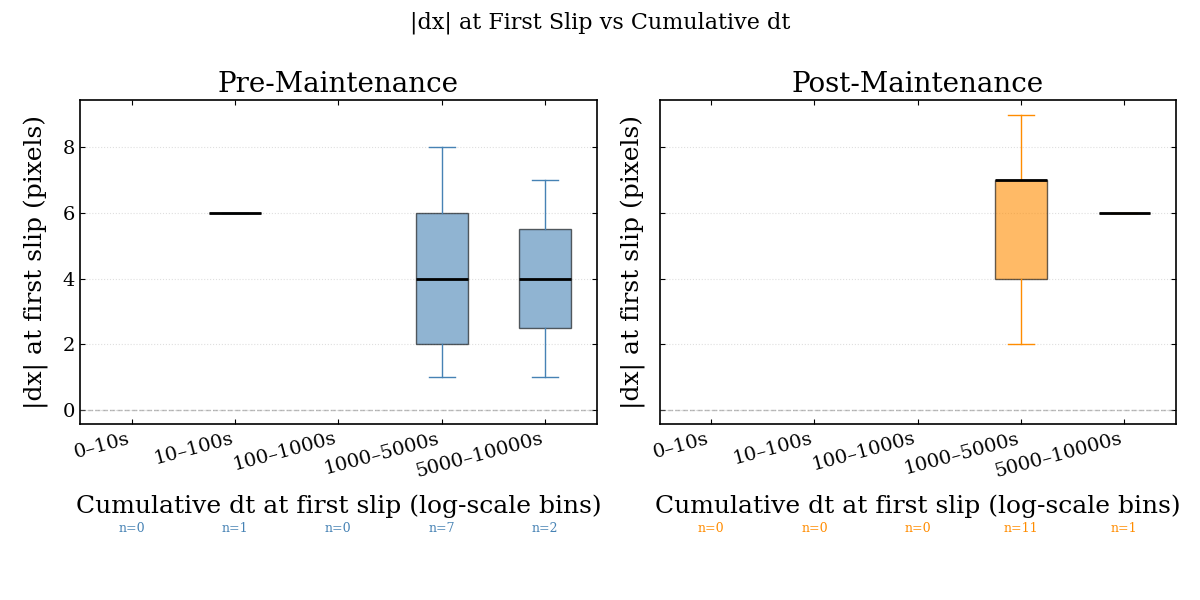

In [71]:
def plot_dx_vs_dt_boxplot(grouped_arc_files_pre: list[dict], grouped_arc_files_post: list[dict]) -> None:
    """
    Plots |dx| at first slip vs cumulative dt at first slip, binned in log scale.
    One plot for pre-maintenance, one for post-maintenance.

    Bins: 0-10s, 10-100s, 100-1000s, 1000-5000s, 5000-10000s
    - First slip defined as first file where dx != 0 and |dx| < 20 and conf >= 0.8
    - dx values are absolute
    """
    CONF_THRESHOLD = 0.8
    DX_MASK        = 20
    BIN_EDGES      = [0, 10, 100, 1000, 5000, 10000]
    BIN_LABELS     = ["0–10s", "10–100s", "100–1000s", "1000–5000s", "5000–10000s"]

    def extract_first_slip(grouped_arc_files):
        first_slips = []
        for g in grouped_arc_files:
            cumulative_dt = np.cumsum(g["delta_time_seconds"])
            for i in range(1, len(g["dx"])):
                dx   = g["dx"][i]
                conf = g["confidence_scores"][i]
                if np.isnan(dx):
                    continue
                if abs(dx) >= DX_MASK:
                    continue
                if conf < CONF_THRESHOLD:
                    continue
                if dx != 0:
                    first_slips.append((cumulative_dt[i], abs(dx)))
                    break
        return first_slips

    def bin_slips(slips):
        binned = {label: [] for label in BIN_LABELS}
        for dt, dx in slips:
            for i in range(len(BIN_EDGES) - 1):
                if BIN_EDGES[i] <= dt < BIN_EDGES[i + 1]:
                    binned[BIN_LABELS[i]].append(dx)
                    break
        return binned

    slips_pre  = extract_first_slip(grouped_arc_files_pre)
    slips_post = extract_first_slip(grouped_arc_files_post)

    binned_pre  = bin_slips(slips_pre)
    binned_post = bin_slips(slips_post)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    for ax, binned, color, title in [
        (axes[0], binned_pre,  "steelblue",  "Pre-Maintenance"),
        (axes[1], binned_post, "darkorange", "Post-Maintenance"),
    ]:
        data      = [binned[bl] for bl in BIN_LABELS]
        positions = np.arange(len(BIN_LABELS))

        # bp = ax.boxplot(
        #     data,
        #     positions=positions,
        #     widths=0.5,
        #     patch_artist=True,
        #     boxprops=dict(facecolor=color, alpha=0.6),
        #     medianprops=dict(color="black", linewidth=2),
        #     whiskerprops=dict(color=color),
        #     capprops=dict(color=color),
        #     flierprops=dict(marker="o", color=color, alpha=0.5),
        # )
        bp = ax.boxplot(
                data,
                positions=positions,
                widths=0.5,
                whis=[0, 100],
                patch_artist=True,
                boxprops=dict(facecolor=color, alpha=0.6),
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(color=color),
                capprops=dict(color=color),
                flierprops=dict(marker="o", color=color, alpha=0.5),
            )

        # Annotate with n per bin
        for pos, d in zip(positions, data):
            ax.text(
                pos, -0.3,
                f"n={len(d)}",
                ha="center", va="top", fontsize=9, color=color,
                transform=ax.get_xaxis_transform()
            )

        ax.set_xticks(positions)
        ax.set_xticklabels(BIN_LABELS, rotation=15, ha="right")
        ax.set_xlabel("Cumulative dt at first slip (log-scale bins)")
        ax.set_ylabel("|dx| at first slip (pixels)")
        ax.set_title(title)
        ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.5)
        ax.grid(axis="y", linestyle=":", alpha=0.4)

    fig.suptitle("|dx| at First Slip vs Cumulative dt", fontsize=16)
    plt.tight_layout()
    plt.show()


plot_dx_vs_dt_boxplot(grouped_arc_files_pre, grouped_arc_files_post)

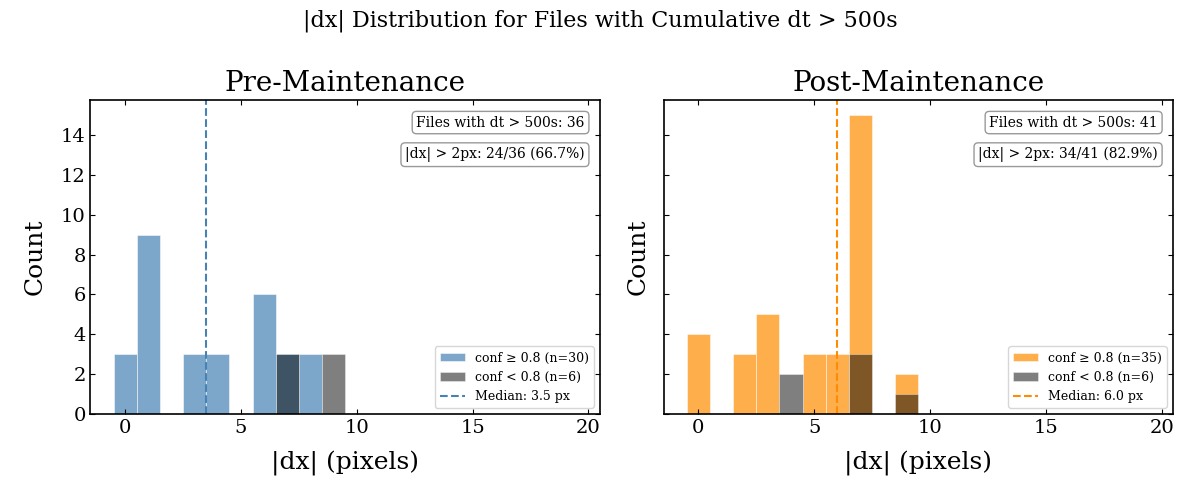

In [89]:
def plot_dx_histogram_dt_filtered(grouped_arc_files_pre: list[dict], grouped_arc_files_post: list[dict]) -> None:
    """
    Plots histogram of |dx| for files where cumulative dt > 500s.

    - |dx| < 20 px quality mask applied
    - Low confidence (< 0.8) shown in black
    - Pre and post as separate side-by-side plots
    """
    CONF_THRESHOLD = 0.8
    DX_MASK        = 20
    DT_THRESHOLD   = 500

    def extract_dx_dt_filtered(grouped_arc_files):
        dx_high, dx_low = [], []
        n_total = 0
        for g in grouped_arc_files:
            cumulative_dt = np.cumsum(g["delta_time_seconds"])
            for i in range(len(g["dx"])):
                dt   = cumulative_dt[i]
                dx   = g["dx"][i]
                conf = g["confidence_scores"][i]

                if dt <= DT_THRESHOLD:
                    continue
                if np.isnan(dx):
                    continue
                if abs(dx) >= DX_MASK:
                    continue

                n_total += 1
                if conf >= CONF_THRESHOLD:
                    dx_high.append(abs(dx))
                else:
                    dx_low.append(abs(dx))

        return np.array(dx_high), np.array(dx_low), n_total

    dx_pre_high,  dx_pre_low,  n_pre  = extract_dx_dt_filtered(grouped_arc_files_pre)
    dx_post_high, dx_post_low, n_post = extract_dx_dt_filtered(grouped_arc_files_post)

    all_vals = np.concatenate([dx_pre_high, dx_pre_low, dx_post_high, dx_post_low])
    if len(all_vals) == 0:
        logger.warning("No files found with cumulative dt > 500s.")
        return
    bins = np.arange(-0.5, DX_MASK + 0.5, 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, dx_high, dx_low, color, title, n_total in [
        (axes[0], dx_pre_high,  dx_pre_low,  "steelblue",  "Pre-Maintenance",  n_pre),
        (axes[1], dx_post_high, dx_post_low, "darkorange", "Post-Maintenance", n_post),
    ]:
        ax.hist(dx_high, bins=bins, alpha=0.7, color=color,   edgecolor="white", linewidth=0.5, label=f"conf ≥ 0.8 (n={len(dx_high)})")
        ax.hist(dx_low,  bins=bins, alpha=0.5, color="black", edgecolor="white", linewidth=0.5, label=f"conf < 0.8 (n={len(dx_low)})")

        if len(dx_high) > 0:
            ax.axvline(np.median(dx_high), color=color, linestyle="--", linewidth=1.5, label=f"Median: {np.median(dx_high):.1f} px")

        # Count annotation
        ax.text(
            0.97, 0.95,
            f"Files with dt > {DT_THRESHOLD}s: {n_total}",
            transform=ax.transAxes,
            ha="right", va="top", fontsize=10,
            bbox=dict(facecolor="white", edgecolor="gray", alpha=0.8, boxstyle="round,pad=0.3")
        )
        n_dx_gt2 = np.sum(dx_high > 2) + np.sum(dx_low > 2)
        ratio     = n_dx_gt2 / n_total if n_total > 0 else 0

        ax.text(
            0.97, 0.85,
            f"|dx| > 2px: {n_dx_gt2}/{n_total} ({ratio:.1%})",
            transform=ax.transAxes,
            ha="right", va="top", fontsize=10,
            bbox=dict(facecolor="white", edgecolor="gray", alpha=0.8, boxstyle="round,pad=0.3")
        )

        ax.set_xlabel("|dx| (pixels)")
        ax.set_ylabel("Count")
        ax.set_title(title)
        ax.legend(fontsize=9, loc = "lower right")

    fig.suptitle(f"|dx| Distribution for Files with Cumulative dt > {DT_THRESHOLD}s", fontsize=16)
    plt.tight_layout()
    plt.show()


plot_dx_histogram_dt_filtered(grouped_arc_files_pre, grouped_arc_files_post)

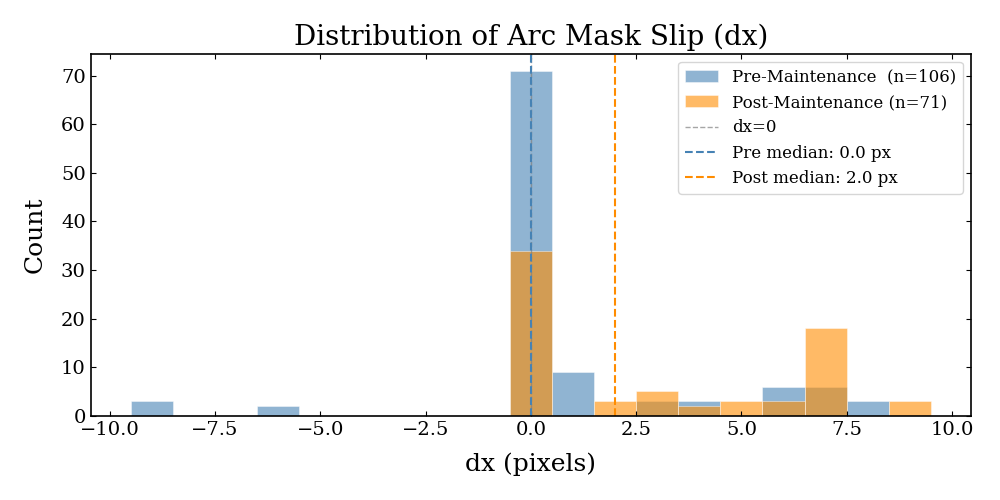

In [58]:
def plot_dx_histogram(grouped_arc_files_pre: list[dict], grouped_arc_files_post: list[dict]) -> None:
    """
    Plots overlapping histograms of dx values for pre and post maintenance.
    
    - First file of each group is excluded (dx=0 by construction, autocorrelated)
    - Bin width: 1 pixel
    """
    dx_pre  = [g["dx"][i] for g in grouped_arc_files_pre  for i in range(1, len(g["dx"]))  if not np.isnan(g["dx"][i]) and abs(g["dx"][i]) < 20]
    dx_post = [g["dx"][i] for g in grouped_arc_files_post for i in range(1, len(g["dx"]))  if not np.isnan(g["dx"][i]) and abs(g["dx"][i]) < 20]

    dx_pre  = np.array(dx_pre)
    dx_post = np.array(dx_post)

    # Integer bins centered on each pixel value
    all_vals = np.concatenate([dx_pre, dx_post])
    bins     = np.arange(all_vals.min() - 0.5, all_vals.max() + 1.5, 1)

    fig, ax = plt.subplots()

    ax.hist(dx_pre,  bins=bins, alpha=0.6, color="steelblue",  label=f"Pre-Maintenance  (n={len(dx_pre)})",  edgecolor="white", linewidth=0.5)
    ax.hist(dx_post, bins=bins, alpha=0.6, color="darkorange", label=f"Post-Maintenance (n={len(dx_post)})", edgecolor="white", linewidth=0.5)

    ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="dx=0")
    ax.axvline(np.median(dx_pre),  color="steelblue",  linestyle="--", linewidth=1.5, label=f"Pre median: {np.median(dx_pre):.1f} px")
    ax.axvline(np.median(dx_post), color="darkorange", linestyle="--", linewidth=1.5, label=f"Post median: {np.median(dx_post):.1f} px")

    ax.set_xlabel("dx (pixels)")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of Arc Mask Slip (dx)")
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_dx_histogram(grouped_arc_files_pre, grouped_arc_files_post)

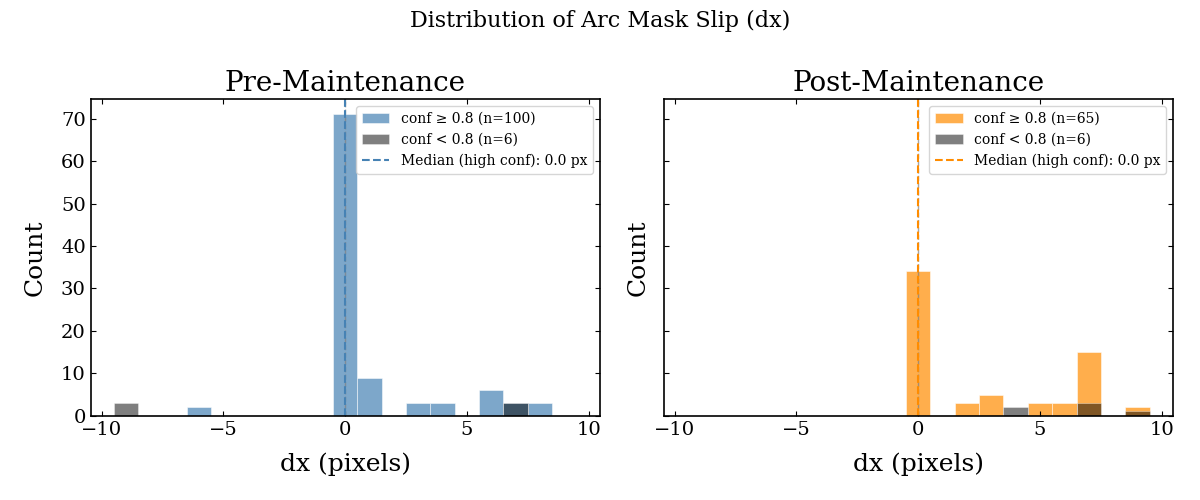

In [60]:
def plot_dx_histogram(grouped_arc_files_pre: list[dict], grouped_arc_files_post: list[dict]) -> None:
    """
    Plots dx histograms for pre and post maintenance side by side.

    - First file of each group excluded (autocorrelated)
    - |dx| < 20 px quality mask applied
    - Low confidence (< 0.8) points overlaid in black
    """
    CONF_THRESHOLD = 0.8
    DX_MASK        = 20

    def extract_dx(grouped_arc_files):
        dx_high, dx_low = [], []
        for g in grouped_arc_files:
            for i in range(1, len(g["dx"])):
                dx   = g["dx"][i]
                conf = g["confidence_scores"][i]
                if np.isnan(dx) or abs(dx) >= DX_MASK:
                    continue
                if conf >= CONF_THRESHOLD:
                    dx_high.append(dx)
                else:
                    dx_low.append(dx)
        return np.array(dx_high), np.array(dx_low)

    dx_pre_high,  dx_pre_low  = extract_dx(grouped_arc_files_pre)
    dx_post_high, dx_post_low = extract_dx(grouped_arc_files_post)

    all_vals = np.concatenate([dx_pre_high, dx_pre_low, dx_post_high, dx_post_low])
    bins     = np.arange(all_vals.min() - 0.5, all_vals.max() + 1.5, 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, dx_high, dx_low, color, title in [
        (axes[0], dx_pre_high,  dx_pre_low,  "steelblue",  "Pre-Maintenance"),
        (axes[1], dx_post_high, dx_post_low, "darkorange", "Post-Maintenance"),
    ]:
        ax.hist(dx_high, bins=bins, alpha=0.7, color=color,   edgecolor="white", linewidth=0.5, label=f"conf ≥ 0.8 (n={len(dx_high)})")
        ax.hist(dx_low,  bins=bins, alpha=0.5, color="black", edgecolor="white", linewidth=0.5, label=f"conf < 0.8 (n={len(dx_low)})")

        ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)

        if len(dx_high) > 0:
            ax.axvline(np.median(dx_high), color=color, linestyle="--", linewidth=1.5, label=f"Median (high conf): {np.median(dx_high):.1f} px")

        ax.set_xlabel("dx (pixels)")
        ax.set_ylabel("Count")
        ax.set_title(title)
        ax.legend(fontsize=10)

    fig.suptitle("Distribution of Arc Mask Slip (dx)", fontsize=16)
    plt.tight_layout()
    plt.show()


plot_dx_histogram(grouped_arc_files_pre, grouped_arc_files_post)

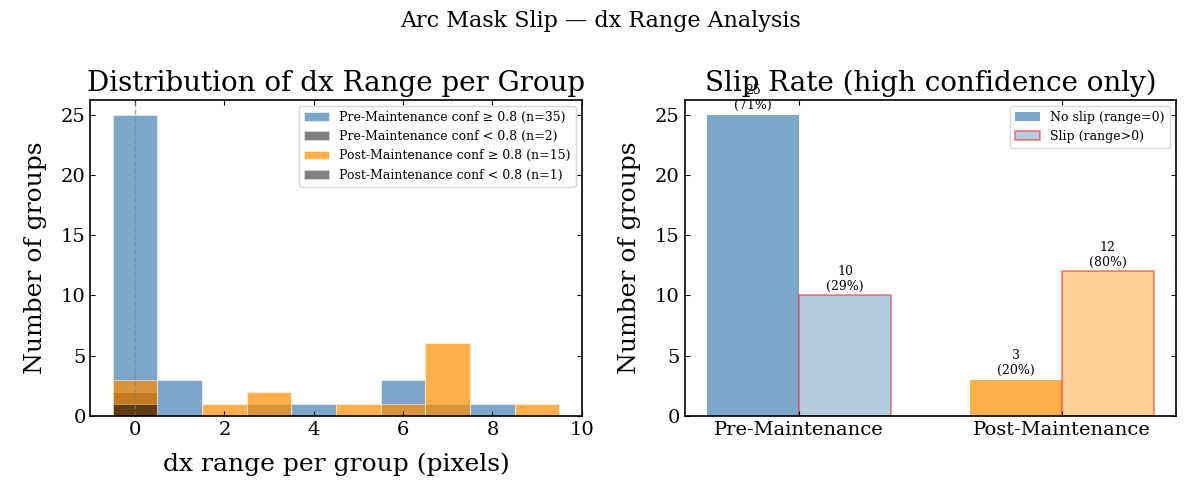

In [61]:
def plot_dx_range(grouped_arc_files_pre: list[dict], grouped_arc_files_post: list[dict]) -> None:
    """
    Plots dx range (max - min) per group for pre and post maintenance.

    Left panel:  histogram of dx range values
    Right panel: bar chart of slip rate (range=0 vs range>0)

    - |dx| < 20 px quality mask applied per file
    - Low confidence (< 0.8) points excluded from range calculation
    """
    CONF_THRESHOLD = 0.8
    DX_MASK        = 20

    def extract_ranges(grouped_arc_files):
        ranges_high, ranges_low = [], []
        for g in grouped_arc_files:
            dx_high = [
                g["dx"][i] for i in range(len(g["dx"]))
                if not np.isnan(g["dx"][i])
                and abs(g["dx"][i]) < DX_MASK
                and g["confidence_scores"][i] >= CONF_THRESHOLD
            ]
            dx_low = [
                g["dx"][i] for i in range(len(g["dx"]))
                if not np.isnan(g["dx"][i])
                and abs(g["dx"][i]) < DX_MASK
                and g["confidence_scores"][i] < CONF_THRESHOLD
            ]
            if len(dx_high) > 1:
                ranges_high.append(max(dx_high) - min(dx_high))
            if len(dx_low) > 1:
                ranges_low.append(max(dx_low) - min(dx_low))

        return np.array(ranges_high), np.array(ranges_low)

    ranges_pre_high,  ranges_pre_low  = extract_ranges(grouped_arc_files_pre)
    ranges_post_high, ranges_post_low = extract_ranges(grouped_arc_files_post)

    all_vals = np.concatenate([ranges_pre_high, ranges_pre_low, ranges_post_high, ranges_post_low])
    bins     = np.arange(all_vals.min() - 0.5, all_vals.max() + 1.5, 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Left: Histogram of dx range ---
    ax = axes[0]
    for ranges_high, ranges_low, color, label in [
        (ranges_pre_high,  ranges_pre_low,  "steelblue",  "Pre-Maintenance"),
        (ranges_post_high, ranges_post_low, "darkorange", "Post-Maintenance"),
    ]:
        ax.hist(ranges_high, bins=bins, alpha=0.7, color=color,   edgecolor="white", linewidth=0.5, label=f"{label} conf ≥ 0.8 (n={len(ranges_high)})")
        ax.hist(ranges_low,  bins=bins, alpha=0.5, color="black", edgecolor="white", linewidth=0.5, label=f"{label} conf < 0.8 (n={len(ranges_low)})")

    ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xlabel("dx range per group (pixels)")
    ax.set_ylabel("Number of groups")
    ax.set_title("Distribution of dx Range per Group")
    ax.legend(fontsize=9)

    # --- Right: Slip rate bar chart ---
    ax = axes[1]

    def slip_rate(ranges):
        n_total   = len(ranges)
        n_slipped = np.sum(ranges > 0)
        n_stable  = n_total - n_slipped
        return n_total, n_slipped, n_stable

    n_pre_total,  n_pre_slipped,  n_pre_stable  = slip_rate(ranges_pre_high)
    n_post_total, n_post_slipped, n_post_stable = slip_rate(ranges_post_high)

    x      = np.array([0, 1])
    width  = 0.35

    bars_stable  = ax.bar(x - width/2, [n_pre_stable,  n_post_stable],  width, label="No slip (range=0)", color=["steelblue", "darkorange"], alpha=0.7)
    bars_slipped = ax.bar(x + width/2, [n_pre_slipped, n_post_slipped], width, label="Slip (range>0)",    color=["steelblue", "darkorange"], alpha=0.4, edgecolor="red", linewidth=1.5)

    # Annotate bars with percentage
    for bars, counts, totals in [
        (bars_stable,  [n_pre_stable,  n_post_stable],  [n_pre_total, n_post_total]),
        (bars_slipped, [n_pre_slipped, n_post_slipped], [n_pre_total, n_post_total]),
    ]:
        for bar, count, total in zip(bars, counts, totals):
            pct = 100 * count / total if total > 0 else 0
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.2,
                f"{count}\n({pct:.0f}%)",
                ha="center", va="bottom", fontsize=9
            )

    ax.set_xticks(x)
    ax.set_xticklabels(["Pre-Maintenance", "Post-Maintenance"])
    ax.set_ylabel("Number of groups")
    ax.set_title("Slip Rate (high confidence only)")
    ax.legend(fontsize=9)

    fig.suptitle("Arc Mask Slip — dx Range Analysis", fontsize=16)
    plt.tight_layout()
    plt.show()


plot_dx_range(grouped_arc_files_pre, grouped_arc_files_post)

In [62]:
def print_dt_stats_stable_groups(grouped_arc_files_pre: list[dict], grouped_arc_files_post: list[dict]) -> None:
    """
    Prints mean and median delta_time_seconds for groups where dx range = 0 (no slip detected).
    High confidence only (conf >= 0.8), |dx| < 20 px mask applied.
    """
    CONF_THRESHOLD = 0.8
    DX_MASK        = 20

    def extract_stable_dt(grouped_arc_files):
        stable_dt = []
        for g in grouped_arc_files:
            dx_high = [
                g["dx"][i] for i in range(len(g["dx"]))
                if not np.isnan(g["dx"][i])
                and abs(g["dx"][i]) < DX_MASK
                and g["confidence_scores"][i] >= CONF_THRESHOLD
            ]
            if len(dx_high) > 1 and (max(dx_high) - min(dx_high)) == 0:
                stable_dt.extend(g["delta_time_seconds"])
        return np.array(stable_dt)

    dt_pre  = extract_stable_dt(grouped_arc_files_pre)
    dt_post = extract_stable_dt(grouped_arc_files_post)

    table = Table(title="dt Stats for Stable Groups (dx range = 0, high confidence)")
    table.add_column("Maintenance Status", style="cyan")
    table.add_column("N groups",           style="magenta", justify="right")
    table.add_column("Mean dt (s)",        style="green",   justify="right")
    table.add_column("Median dt (s)",      style="green",   justify="right")

    for dt, label in [(dt_pre, "Pre-Maintenance"), (dt_post, "Post-Maintenance")]:
        table.add_row(
            label,
            str(len(dt)),
            f"{np.mean(dt):.1f}",
            f"{np.median(dt):.1f}",
        )

    Console().print(table)


print_dt_stats_stable_groups(grouped_arc_files_pre, grouped_arc_files_post)

  dt Stats for Stable Groups (dx range = 0, high confidence)   
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Maintenance Status ┃ N groups ┃ Mean dt (s) ┃ Median dt (s) ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Pre-Maintenance    │       81 │        89.3 │          11.3 │
│ Post-Maintenance   │       12 │       119.7 │          11.3 │
└────────────────────┴──────────┴─────────────┴───────────────┘

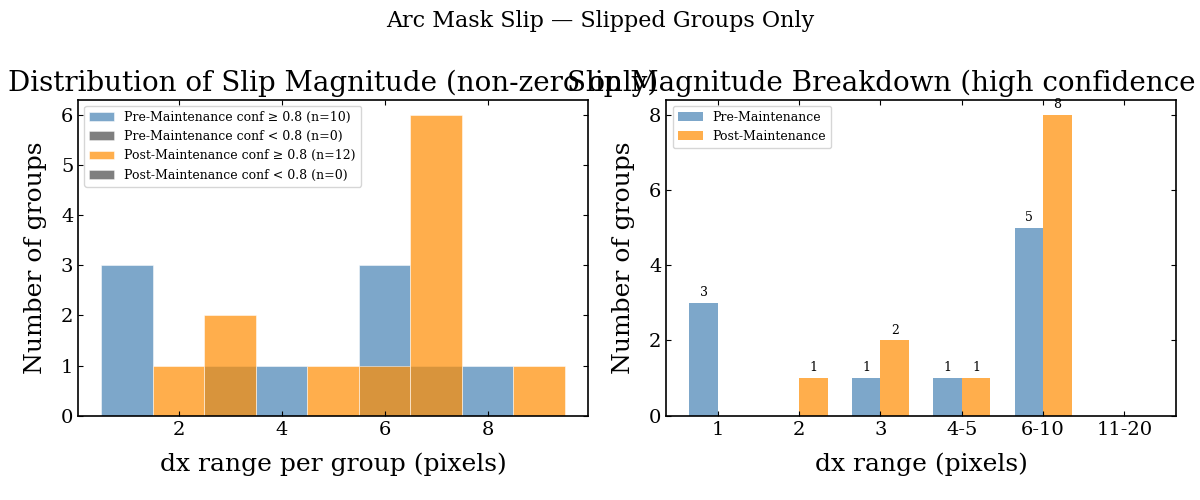

In [65]:
def plot_dx_range_slipped(grouped_arc_files_pre: list[dict], grouped_arc_files_post: list[dict]) -> None:
    """
    Same as plot_dx_range but restricted to groups where dx range > 0 (slip detected).

    Left panel:  histogram of non-zero dx range values
    Right panel: breakdown of slip magnitude bins
    """
    CONF_THRESHOLD = 0.8
    DX_MASK        = 20

    def extract_ranges(grouped_arc_files):
        ranges_high, ranges_low = [], []
        for g in grouped_arc_files:
            dx_high = [
                g["dx"][i] for i in range(len(g["dx"]))
                if not np.isnan(g["dx"][i])
                and abs(g["dx"][i]) < DX_MASK
                and g["confidence_scores"][i] >= CONF_THRESHOLD
            ]
            dx_low = [
                g["dx"][i] for i in range(len(g["dx"]))
                if not np.isnan(g["dx"][i])
                and abs(g["dx"][i]) < DX_MASK
                and g["confidence_scores"][i] < CONF_THRESHOLD
            ]
            if len(dx_high) > 1:
                ranges_high.append(max(dx_high) - min(dx_high))
            if len(dx_low) > 1:
                ranges_low.append(max(dx_low) - min(dx_low))

        return np.array(ranges_high), np.array(ranges_low)

    ranges_pre_high,  ranges_pre_low  = extract_ranges(grouped_arc_files_pre)
    ranges_post_high, ranges_post_low = extract_ranges(grouped_arc_files_post)

    # Keep only non-zero ranges
    slipped_pre_high  = ranges_pre_high[ranges_pre_high   > 0]
    slipped_pre_low   = ranges_pre_low[ranges_pre_low     > 0]
    slipped_post_high = ranges_post_high[ranges_post_high > 0]
    slipped_post_low  = ranges_post_low[ranges_post_low   > 0]

    all_vals = np.concatenate([slipped_pre_high, slipped_pre_low, slipped_post_high, slipped_post_low])
    if len(all_vals) == 0:
        logger.warning("No slipped groups found — nothing to plot.")
        return
    bins = np.arange(all_vals.min() - 0.5, all_vals.max() + 1.5, 1)

    # Magnitude bins for right panel
    mag_bins   = [1, 2, 3, 5, 10, 20]
    mag_labels = ["1", "2", "3", "4-5", "6-10", "11-20"]

    def magnitude_counts(ranges):
        edges = [0, 1, 2, 3, 5, 10, 20]
        return [np.sum((ranges > edges[i]) & (ranges <= edges[i+1])) for i in range(len(edges)-1)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Left: Histogram of non-zero dx range ---
    ax = axes[0]
    for slipped_high, slipped_low, color, label in [
        (slipped_pre_high,  slipped_pre_low,  "steelblue",  "Pre-Maintenance"),
        (slipped_post_high, slipped_post_low, "darkorange", "Post-Maintenance"),
    ]:
        ax.hist(slipped_high, bins=bins, alpha=0.7, color=color,   edgecolor="white", linewidth=0.5, label=f"{label} conf ≥ 0.8 (n={len(slipped_high)})")
        ax.hist(slipped_low,  bins=bins, alpha=0.5, color="black", edgecolor="white", linewidth=0.5, label=f"{label} conf < 0.8 (n={len(slipped_low)})")

    ax.set_xlabel("dx range per group (pixels)")
    ax.set_ylabel("Number of groups")
    ax.set_title("Distribution of Slip Magnitude (non-zero only)")
    ax.legend(fontsize=9)

    # --- Right: Magnitude breakdown ---
    ax   = axes[1]
    x    = np.arange(len(mag_labels))
    width = 0.35

    counts_pre  = magnitude_counts(slipped_pre_high)
    counts_post = magnitude_counts(slipped_post_high)

    bars_pre  = ax.bar(x - width/2, counts_pre,  width, color="steelblue",  alpha=0.7, label="Pre-Maintenance")
    bars_post = ax.bar(x + width/2, counts_post, width, color="darkorange", alpha=0.7, label="Post-Maintenance")

    for bars, counts in [(bars_pre, counts_pre), (bars_post, counts_post)]:
        for bar, count in zip(bars, counts):
            if count > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.1,
                    str(count),
                    ha="center", va="bottom", fontsize=9
                )

    ax.set_xticks(x)
    ax.set_xticklabels(mag_labels)
    ax.set_xlabel("dx range (pixels)")
    ax.set_ylabel("Number of groups")
    ax.set_title("Slip Magnitude Breakdown (high confidence only)")
    ax.legend(fontsize=9)

    fig.suptitle("Arc Mask Slip — Slipped Groups Only", fontsize=16)
    plt.tight_layout()
    plt.show()


plot_dx_range_slipped(grouped_arc_files_pre, grouped_arc_files_post)

In [64]:
def print_dt_stats_slipped_groups(grouped_arc_files_pre: list[dict], grouped_arc_files_post: list[dict]) -> None:
    """
    Prints mean and median delta_time_seconds for groups where dx range > 0 (slip detected).
    High confidence only (conf >= 0.8), |dx| < 20 px mask applied.
    """
    CONF_THRESHOLD = 0.8
    DX_MASK        = 20

    def extract_slipped_dt(grouped_arc_files):
        slipped_dt = []
        for g in grouped_arc_files:
            dx_high = [
                g["dx"][i] for i in range(len(g["dx"]))
                if not np.isnan(g["dx"][i])
                and abs(g["dx"][i]) < DX_MASK
                and g["confidence_scores"][i] >= CONF_THRESHOLD
            ]
            if len(dx_high) > 1 and (max(dx_high) - min(dx_high)) > 0:
                slipped_dt.extend(g["delta_time_seconds"])
        return np.array(slipped_dt)

    dt_pre  = extract_slipped_dt(grouped_arc_files_pre)
    dt_post = extract_slipped_dt(grouped_arc_files_post)

    table = Table(title="dt Stats for Slipped Groups (dx range > 0, high confidence)")
    table.add_column("Maintenance Status", style="cyan")
    table.add_column("N groups",           style="magenta", justify="right")
    table.add_column("Mean dt (s)",        style="green",   justify="right")
    table.add_column("Median dt (s)",      style="green",   justify="right")

    for dt, label in [(dt_pre, "Pre-Maintenance"), (dt_post, "Post-Maintenance")]:
        table.add_row(
            label,
            str(len(dt)),
            f"{np.mean(dt):.1f}" if len(dt) > 0 else "N/A",
            f"{np.median(dt):.1f}" if len(dt) > 0 else "N/A",
        )

    Console().print(table)


print_dt_stats_slipped_groups(grouped_arc_files_pre, grouped_arc_files_post)

  dt Stats for Slipped Groups (dx range > 0, high confidence)  
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Maintenance Status ┃ N groups ┃ Mean dt (s) ┃ Median dt (s) ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Pre-Maintenance    │       60 │       495.9 │          11.4 │
│ Post-Maintenance   │       75 │       506.1 │          11.4 │
└────────────────────┴──────────┴─────────────┴───────────────┘

In [ ]:
def read_fits_file(file):
    with fits.open(file) as hdul:
        header = hdul[0].header
        for i in range(1, len(hdul)):
            header.update(hdul[i].header)
        data = {i: hdul[i].data for i in range(len(hdul))}
    return header, data

    
def find_lamp_type(header):
    # List of the standard Goodman calibration lamp keywords
    lamp_mapping = {
        "LAMP_HGA": "HgAr",
        "LAMP_NE": "Ne",
        "LAMP_AR": "Ar",
        "LAMP_FE": "Fe",
        "LAMP_CU": "Cu",
        "LAMP_QUA": "Quartz",
    }

    Lamps = tuple(
        name 
        for kw, name in lamp_mapping.items() 
        if header.get(kw) in [True, "TRUE", "T"]
    )

    lamp_str = "+".join(Lamps) if Lamps else "Unknown"

    return lamp_str

def gaussian(x, A, mu, sigma, offset):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset

In [ ]:
run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
logger, fh = get_logger(f"run_{run_timestamp}.log")


pre_maintaince = "/Users/ani/local/data/soar/mask_slip/pre_maintainance/spectroscopy"
post_maintaince = "/Users/ani/local/data/soar/mask_slip/post_maintainance/spectroscopy"

pre_maintaince_files = get_all_fits_files(pre_maintaince)
post_maintaince_files = get_all_fits_files(post_maintaince)


good_pre_files  = filter_fits_files(pre_maintaince_files)
good_post_files = filter_fits_files(post_maintaince_files)

logger.info(f"Pre-maintenance:  {len(good_pre_files)}  / {len(pre_maintaince_files)}  files kept")
logger.info(f"Post-maintenance: {len(good_post_files)} / {len(post_maintaince_files)} files kept")

In [ ]:
arcs_metadata_pre = []
for good_file in good_pre_files:
    header, data = read_fits_file(good_file)
    lamp = find_lamp_type(header)
    filename = os.path.basename(good_file)
    file_path = os.path.dirname(good_file)
    date, datetime, grating = header['DATE'], header["DATE-OBS"], header['WAVMODE']
    
    arcs_metadata_pre.append({
        "filename": filename,
        "file_path": file_path,
        "date": date,
        "datetime": datetime,
        "grating": grating,
        "lamps": lamp,
        "object": header.get("OBJECT", "N/A"),
    }) 

groups_pre = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for entry in arcs_metadata_pre:
    date = entry["date"]
    datetime = entry["datetime"]
    obj = entry["object"]
    grating = entry["grating"]

    if grating in ["400_M1", "400_M2"]:
        logger.info(f"Grouping file: {entry['filename']} — Date: {date}, OBJECT: {obj}, Grating: {grating}")
        groups_pre[date][obj][grating].append(entry)
    else:
        logger.warning(f"Skipping file with unexpected grating: {entry['filename']} — Grating: {grating}")

In [ ]:
arcs_metadata_post = []
for good_file in good_post_files:
    header, data = read_fits_file(good_file)
    lamp = find_lamp_type(header)
    filename = os.path.basename(good_file)
    file_path = os.path.dirname(good_file)
    date, datetime, grating = header['DATE'], header["DATE-OBS"], header['WAVMODE']
    
    arcs_metadata_post.append({
        "filename": filename,
        "file_path": file_path,
        "date": date,
        "datetime": datetime,
        "grating": grating,
        "lamps": lamp,
        "object": header.get("OBJECT", "N/A"),
    }) 

groups_post = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for entry in arcs_metadata_post:
    date = entry["date"]
    datetime = entry["datetime"]
    obj = entry["object"]
    grating = entry["grating"]

    if grating in ["400_M1", "400_M2"]:
        logger.info(f"Grouping file: {entry['filename']} — Date: {date}, OBJECT: {obj}, Grating: {grating}")
        groups_post[date][obj][grating].append(entry)
    else:
        logger.warning(f"Skipping file with unexpected grating: {entry['filename']} — Grating: {grating}")

In [ ]:
grouped_arc_files_pre = []
for date in groups_pre.keys():
    for obj in groups_pre[date].keys():
        for grating in groups_pre[date][obj].keys():
            arc_files = groups_pre[date][obj][grating]
            count = len(arc_files)
            sorted_files = sorted(arc_files, key=lambda x: x["datetime"])
            if count < 4:
                print(f"Not enough files to analyze for Date: {date}, OBJECT: {obj}, Grating: {grating} — Count: {count}")
                continue

            previous_file_datetime = None
            print("-"*50)
            print(f"Date: {date}, OBJECT: {obj}, Grating: {grating}, Count: {count}")

            delta_file_datetime_seconds_all = []
            for arc_file in sorted_files:
                
                filename = arc_file["filename"]
                current_file_datetime = (Time(arc_file["datetime"])).to_datetime()

                if previous_file_datetime is None:
                    delta_file_datetime_seconds = 0
                else:
                    delta_file_datetime_seconds = (current_file_datetime - previous_file_datetime).total_seconds()

                print(f"  - {filename}, dt = {delta_file_datetime_seconds} seconds")
                delta_file_datetime_seconds_all.append(delta_file_datetime_seconds)

                previous_file_datetime = current_file_datetime

            grouped_arc_files_pre.append({
            "date": date,
            "object": obj,
            "grating": grating,
            "lamps": arc_files[0]["lamps"],
            "arc_files": [arc_file["filename"] for arc_file in sorted_files],
            "file_paths": [arc_file["file_path"] for arc_file in sorted_files],
            "datetimes": [arc_file["datetime"] for arc_file in sorted_files],
            "delta_time_seconds": delta_file_datetime_seconds_all,
        })

In [ ]:
grouped_arc_files_post = []
for date in groups_post.keys():
    for obj in groups_post[date].keys():
        for grating in groups_post[date][obj].keys():
            arc_files = groups_post[date][obj][grating]
            count = len(arc_files)
            sorted_files = sorted(arc_files, key=lambda x: x["datetime"])
            if count < 4:
                print(f"Not enough files to analyze for Date: {date}, OBJECT: {obj}, Grating: {grating} — Count: {count}")
                continue

            previous_file_datetime = None
            print("-"*50)
            print(f"Date: {date}, OBJECT: {obj}, Grating: {grating}, Count: {count}")

            delta_file_datetime_seconds_all = []
            for arc_file in sorted_files:
                
                filename = arc_file["filename"]
                current_file_datetime = (Time(arc_file["datetime"])).to_datetime()

                if previous_file_datetime is None:
                    delta_file_datetime_seconds = 0
                else:
                    delta_file_datetime_seconds = (current_file_datetime - previous_file_datetime).total_seconds()

                print(f"  - {filename}, dt = {delta_file_datetime_seconds} seconds")
                delta_file_datetime_seconds_all.append(delta_file_datetime_seconds)

                previous_file_datetime = current_file_datetime

            grouped_arc_files_post.append({
            "date": date,
            "object": obj,
            "grating": grating,
            "lamps": arc_files[0]["lamps"],
            "arc_files": [arc_file["filename"] for arc_file in sorted_files],
            "file_paths": [arc_file["file_path"] for arc_file in sorted_files],
            "datetimes": [arc_file["datetime"] for arc_file in sorted_files],
            "delta_time_seconds": delta_file_datetime_seconds_all,
        })

In [ ]:
logger.info(f"Starting cross-correlation shift calculation for {len(grouped_arc_files_pre)} groups...")

for group in grouped_arc_files_pre:
    # 1. Reconstruct full file paths for the current group
    files = [
        os.path.join(group["file_paths"][i], group["arc_files"][i]) 
        for i in range(len(group["arc_files"]))
    ]
    
    # Skip if empty (safeguard)
    if not files:
        group["dx"] = []
        continue
        
    # 2. Establish the baseline (File 0 of this specific group)
    reference_file = files[0]
    try:
        _, data = read_fits_file(reference_file)
        arc_image = data[1]
        one_d_spec_reference = np.sum(arc_image, axis=0) 
    except Exception as e:
        logger.error(f"Failed to read reference file {reference_file}: {e}")
        # If the reference fails, we can't do shifts for this group. Fill with NaNs.
        group["dx"] = [np.nan] * len(files) 
        continue
        
    relative_shifts = []
    confidence_scores = []
    
    # 3. Loop through all files in the current group
    for i, current_spectrum_file in enumerate(files):
        try:
            _, data = read_fits_file(current_spectrum_file)
            arc_image = data[1]
            current_spectrum = np.sum(arc_image, axis=0)

            # Cross-correlate against the group's reference spectrum

            correlation = signal.correlate(current_spectrum, one_d_spec_reference, mode='full')
            lags = signal.correlation_lags(len(current_spectrum), len(one_d_spec_reference), mode='full')

            correlation = signal.correlate(current_spectrum, one_d_spec_reference, mode='full')
            lags = signal.correlation_lags(len(current_spectrum), len(one_d_spec_reference), mode='full')

            # 1. Get the integer shift (what you already have)
            best_idx = np.argmax(correlation)
            shift_pixels = lags[best_idx]

            # 2. Get the raw maximum correlation value
            raw_max_correlation = correlation[best_idx]

            # 3. Calculate the normalized score (0.0 to 1.0)
            # We divide the raw correlation by the square root of the auto-correlations
            curr_f = current_spectrum.astype(np.float64)
            ref_f = one_d_spec_reference.astype(np.float64)

            norm_factor = np.sqrt(np.sum(curr_f**2) * np.sum(ref_f**2))
            # norm_factor = np.sqrt(np.sum(current_spectrum**2) * np.sum(one_d_spec_reference**2))
            confidence_score = raw_max_correlation / norm_factor

            print(f"Shift: {shift_pixels} pixels | Confidence Score: {confidence_score:.4f}")
            
            # Extract integer shift
            shift_pixels = lags[np.argmax(correlation)]
            relative_shifts.append(shift_pixels)
            confidence_scores.append(confidence_score)
            
        except Exception as e:
            logger.error(f"Failed to process file {current_spectrum_file}: {e}")
            # Append NaN if a specific file fails so the list length still matches the number of files
            relative_shifts.append(np.nan) 
            
    # 4. Update the dictionary in-place with the new "dx" key
    group["dx"] = relative_shifts
    group["confidence_scores"] = confidence_scores
    
    logger.info(
        f"Processed Date: {group['date']} | Obj: {group['object']} | Grating: {group['grating']} "
        f"— Shifts: {relative_shifts}"
    )

logger.info("Finished calculating all dx shifts.")

In [ ]:
logger.info(f"Starting cross-correlation shift calculation for {len(grouped_arc_files_post)} groups...")

for group in grouped_arc_files_post:
    # 1. Reconstruct full file paths for the current group
    files = [
        os.path.join(group["file_paths"][i], group["arc_files"][i]) 
        for i in range(len(group["arc_files"]))
    ]
    
    # Skip if empty (safeguard)
    if not files:
        group["dx"] = []
        continue
        
    # 2. Establish the baseline (File 0 of this specific group)
    reference_file = files[0]
    try:
        _, data = read_fits_file(reference_file)
        arc_image = data[1]
        one_d_spec_reference = np.sum(arc_image, axis=0) 
    except Exception as e:
        logger.error(f"Failed to read reference file {reference_file}: {e}")
        # If the reference fails, we can't do shifts for this group. Fill with NaNs.
        group["dx"] = [np.nan] * len(files) 
        continue
        
    relative_shifts = []
    confidence_scores = []
    
    # 3. Loop through all files in the current group
    for i, current_spectrum_file in enumerate(files):
        try:
            _, data = read_fits_file(current_spectrum_file)
            arc_image = data[1]
            current_spectrum = np.sum(arc_image, axis=0)

            # Cross-correlate against the group's reference spectrum

            correlation = signal.correlate(current_spectrum, one_d_spec_reference, mode='full')
            lags = signal.correlation_lags(len(current_spectrum), len(one_d_spec_reference), mode='full')

            correlation = signal.correlate(current_spectrum, one_d_spec_reference, mode='full')
            lags = signal.correlation_lags(len(current_spectrum), len(one_d_spec_reference), mode='full')

            # 1. Get the integer shift (what you already have)
            best_idx = np.argmax(correlation)
            shift_pixels = lags[best_idx]
            print(f"Shift: {shift_pixels} pixels", end=" | ")

            # 2. Get the raw maximum correlation value
            raw_max_correlation = correlation[best_idx]

            # 3. Calculate the normalized score (0.0 to 1.0)
            # We divide the raw correlation by the square root of the auto-correlations
            curr_f = current_spectrum.astype(np.float64)
            ref_f = one_d_spec_reference.astype(np.float64)

            norm_factor = np.sqrt(np.sum(curr_f**2) * np.sum(ref_f**2))
            # norm_factor = np.sqrt(np.sum(current_spectrum**2) * np.sum(one_d_spec_reference**2))
            confidence_score = raw_max_correlation / norm_factor

            print(f"Shift: {shift_pixels} pixels | Confidence Score: {confidence_score:.4f}")
            
            # Extract integer shift
            shift_pixels = lags[np.argmax(correlation)]
            relative_shifts.append(shift_pixels)
            confidence_scores.append(confidence_score)
            
        except Exception as e:
            logger.error(f"Failed to process file {current_spectrum_file}: {e}")
            # Append NaN if a specific file fails so the list length still matches the number of files
            relative_shifts.append(np.nan) 
            
    # 4. Update the dictionary in-place with the new "dx" key
    group["dx"] = relative_shifts
    group["confidence_scores"] = confidence_scores
    
    logger.info(
        f"Processed Date: {group['date']} | Obj: {group['object']} | Grating: {group['grating']} "
        f"— Shifts: {relative_shifts}"
    )

logger.info("Finished calculating all dx shifts.")

In [ ]:
df_pre = pd.DataFrame(grouped_arc_files_pre)
df_post = pd.DataFrame(grouped_arc_files_post)

df_pre_exp = df_pre.explode(["dx", "confidence_scores"]).dropna(subset=["dx", "confidence_scores"])
df_post_exp = df_post.explode(["dx", "confidence_scores"]).dropna(subset=["dx", "confidence_scores"])


ptp_pre = df_pre["dx"].apply(lambda x: np.nanmax(x) - np.nanmin(x) if len(x) > 0 else np.nan).dropna()
ptp_pre = ptp_pre[ptp_pre < 20]

# Individual metrics: dx and confidence
dx_pre = df_pre_exp["dx"].values.astype(float)
conf_pre = df_pre_exp["confidence_scores"].values.astype(float)

mask_pre = dx_pre < 20
nonzero_dx_pre = dx_pre[mask_pre]
low_conf_pre = dx_pre[mask_pre & (conf_pre < 0.8)]


ptp_post = df_post["dx"].apply(lambda x: np.nanmax(x) - np.nanmin(x) if len(x) > 0 else np.nan).dropna()
ptp_post = ptp_post[ptp_post < 20]  


dx_post = df_post_exp["dx"].values.astype(float)
conf_post = df_post_exp["confidence_scores"].values.astype(float)

mask_post =  np.abs(dx_post) < 20
nonzero_dx_post = dx_post[mask_post]
low_conf_post = dx_post[mask_post & (conf_post < 0.8)]


fig, axes = plt.subplots(2, 2, figsize=(12, 8))


axes[0, 0].hist(ptp_pre, bins=np.arange(0, ptp_pre.max() + 2) - 0.5, color='C0', alpha=0.6)
axes[0, 0].set_title("PRE: drift: max(dx) - min(dx)")
axes[0, 0].set_xlabel("pixels")
axes[0, 0].set_ylabel("Count")


bins_pre = np.arange(nonzero_dx_pre.min() - 0.5, nonzero_dx_pre.max() + 1.5)
axes[0, 1].hist(nonzero_dx_pre, bins=bins_pre, color='C0', alpha=0.6, label="All shifts")

if len(low_conf_pre) > 0:
    axes[0, 1].hist(low_conf_pre, bins=bins_pre, color='k', edgecolor='white', alpha=0.6, label="Conf < 0.8")

axes[0, 1].set_title("PRE: all dx values")
axes[0, 1].set_xlabel("pixels")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()

if len(ptp_post) > 0:
    axes[1, 0].hist(ptp_post, bins=np.arange(0, ptp_post.max() + 2) - 0.5, color='C2', alpha=0.6)
axes[1, 0].set_title("POST: drift: max(dx) - min(dx)")
axes[1, 0].set_xlabel("pixels")
axes[1, 0].set_ylabel("Count")


if len(nonzero_dx_post) > 0:
    bins_post = np.arange(nonzero_dx_post.min() - 0.5, nonzero_dx_post.max() + 1.5)
    axes[1, 1].hist(nonzero_dx_post, bins=bins_post, color='C2', alpha=0.6, label="All shifts")
    
    if len(low_conf_post) > 0:
        axes[1, 1].hist(low_conf_post, bins=bins_post, color='k', edgecolor='white', alpha=0.6, label="Conf < 0.8")

axes[1, 1].set_title("POST: all dx values")
axes[1, 1].set_xlabel("pixels")
axes[1, 1].set_ylabel("Count")
axes[1, 1].legend()


plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_pre = pd.DataFrame(grouped_arc_files_pre)
df_post = pd.DataFrame(grouped_arc_files_post)


df_pre_exp = df_pre.explode(["dx", "confidence_scores"]).dropna(subset=["dx", "confidence_scores"])
df_post_exp = df_post.explode(["dx", "confidence_scores"]).dropna(subset=["dx", "confidence_scores"])


ptp_pre = df_pre["dx"].apply(lambda x: np.nanmax(x) - np.nanmin(x) if len(x) > 0 else np.nan).dropna()


dx_pre = df_pre_exp["dx"].values.astype(float)
conf_pre = df_pre_exp["confidence_scores"].values.astype(float)

mask_pre = dx_pre != 0
nonzero_dx_pre = dx_pre[mask_pre]
low_conf_pre = dx_pre[mask_pre & (conf_pre < 0.8)]


ptp_post = df_post["dx"].apply(lambda x: np.nanmax(x) - np.nanmin(x) if len(x) > 0 else np.nan).dropna()
ptp_post = ptp_post[ptp_post < 10]  

# Individual metrics: dx and confidence (filtered < 10)
dx_post = df_post_exp["dx"].values.astype(float)
conf_post = df_post_exp["confidence_scores"].values.astype(float)

mask_post = (dx_post != 0) & (np.abs(dx_post) < 10)
nonzero_dx_post = dx_post[mask_post]
low_conf_post = dx_post[mask_post & (conf_post < 0.8)]

# ==========================================
# 4. Create the 2x2 Subplot Grid
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# --- ROW 0: PRE (Color: C0) ---
# [0, 0] Pre: Peak-to-peak
axes[0, 0].hist(ptp_pre, bins=np.arange(0, ptp_pre.max() + 2) - 0.5, color='C0', edgecolor='black', alpha=0.7)
axes[0, 0].set_title("PRE: Peak-to-peak range per group")
axes[0, 0].set_xlabel("max(dx) - min(dx) (pixels)")
axes[0, 0].set_ylabel("Count")

# [0, 1] Pre: Non-zero dx with Black Overlay
bins_pre = np.arange(nonzero_dx_pre.min() - 0.5, nonzero_dx_pre.max() + 1.5)
axes[0, 1].hist(nonzero_dx_pre, bins=bins_pre, color='C0', edgecolor='black', alpha=0.7, label="All shifts")

if len(low_conf_pre) > 0:
    axes[0, 1].hist(low_conf_pre, bins=bins_pre, color='k', edgecolor='white', alpha=0.9, label="Conf < 0.8")

axes[0, 1].set_title("PRE: Non-zero dx values")
axes[0, 1].set_xlabel("Shift (pixels)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()


# --- ROW 1: POST (Color: C2) ---
# [1, 0] Post: Peak-to-peak
if len(ptp_post) > 0:
    axes[1, 0].hist(ptp_post, bins=np.arange(0, ptp_post.max() + 2) - 0.5, color='C2', edgecolor='black', alpha=0.7)
axes[1, 0].set_title("POST: Peak-to-peak range per group (<10px)")
axes[1, 0].set_xlabel("max(dx) - min(dx) (pixels)")
axes[1, 0].set_ylabel("Count")

# [1, 1] Post: Non-zero dx with Black Overlay
if len(nonzero_dx_post) > 0:
    bins_post = np.arange(nonzero_dx_post.min() - 0.5, nonzero_dx_post.max() + 1.5)
    axes[1, 1].hist(nonzero_dx_post, bins=bins_post, color='C2', edgecolor='black', alpha=0.7, label="All shifts")
    
    if len(low_conf_post) > 0:
        axes[1, 1].hist(low_conf_post, bins=bins_post, color='k', edgecolor='white', alpha=0.9, label="Conf < 0.8")

axes[1, 1].set_title("POST: Non-zero dx values (<10px)")
axes[1, 1].set_xlabel("Shift (pixels)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].legend()

# Polish layout
plt.tight_layout()
plt.show()

In [ ]:
from astropy.time import Time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

mid_mjds    = np.array(mid_mjds)
dx_ranges   = np.array(dx_ranges)
dt_firsts   = np.array(dt_firsts)
conf_firsts = np.array(conf_firsts)

print(f"Total points: {len(mid_mjds)}")
print(f"mean dt: {np.mean(dt_firsts):.2f} seconds")

mask      = dx_ranges < 10
high_conf = conf_firsts[mask] > 0.8
low_conf  = ~high_conf

dt_masked = dt_firsts[mask]
norm = LogNorm(vmin=dt_masked.min(), vmax=dt_masked.max())

fig, ax = plt.subplots(figsize=(12, 5))


sc = ax.scatter(
    mid_mjds[mask][high_conf], dx_ranges[mask][high_conf],
    c=dt_masked[high_conf], cmap="plasma", norm=norm,
    s=150, marker="o", edgecolors="black", linewidth=0.5, zorder=4, alpha = 0.6
)


ax.scatter(
    mid_mjds[mask][low_conf], dx_ranges[mask][low_conf],
    c=dt_masked[low_conf], cmap="plasma", norm=norm,
    s=150, marker="^", facecolors="none", linewidth=1.5, zorder=3, alpha = 0.6
)


xmin, xmax = 61097, 61144
ax.axvspan(xmin, xmax, color="slategray", alpha=0.15, zorder=1)
plt.draw()
ax.text(
    (xmin + xmax) / 2, ax.get_ylim()[1] * 0.95,
    "Maintenance\nWindow",
    ha="center", va="top", fontsize=10, color="k", style="italic"
)


median_dx = np.median(dx_ranges[mask])
ax.axhline(median_dx, color="tab:orange", linestyle="--", linewidth=1.5, zorder=2)
ax.text(
    0.85, median_dx + 0.15,
    f"Median: {median_dx:.1f} px",
    transform=ax.get_yaxis_transform(), ha="left", va="bottom",
    fontsize=10, color="tab:orange", fontweight="bold"
)


ax.scatter([], [], marker="o", facecolors="gray", edgecolors="black", linewidth=0.5, s=100, label="Confidence > 0.8")
ax.scatter([], [], marker="^", facecolors="gray", edgecolors="gray", linewidth=1.5, s=100, label="Confidence ≤ 0.8")
ax.legend(loc="upper left", framealpha=0.9, fontsize=10)

cb = plt.colorbar(sc, ax=ax)
cb.set_label("dt before the first shift (seconds)", fontsize=12)

ax.set_xlabel("MJD")
ax.set_ylabel("Drift (dx) [Pixels]")
ax.set_title("Did SOAR's slit slightly slip?")
ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=0)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure()
mask = dx_ranges < 10
plt.scatter(dt_firsts[mask], dx_ranges[mask], c=conf_firsts[mask], cmap="plasma", norm=LogNorm())
plt.colorbar(label="Confidence Score")
plt.xlabel("dt before the first shift (seconds)")
plt.ylabel("Drift (dx) [Pixels]")
plt.title("Drift vs. Time Before First Shift")
plt.show()

In [ ]:
from astropy.time import Time
import numpy as np
import matplotlib.pyplot as plt

mid_mjds, dx_ranges, dt_firsts, conf_firsts = [], [], [], []

for group in grouped_arc_files_pre + grouped_arc_files_post:
    datetimes = group["datetimes"]
    dx = np.array(group["dx"])
    delta_time_seconds = np.array(group["delta_time_seconds"])
    group_conf = np.array(group["confidence_scores"])

    mjds = Time(datetimes, format="isot", scale="utc").mjd
    mid_mjds.append(np.mean(mjds))
    dx_ranges.append(dx.max() - dx.min())

    first_shift_idx = next((i for i in range(1, len(dx)) if dx[i] != dx[i - 1]), None)
    dt_firsts.append(delta_time_seconds[first_shift_idx] if first_shift_idx is not None else 0)
    conf_firsts.append(group_conf[first_shift_idx] if first_shift_idx is not None else 1.0)

mid_mjds    = np.array(mid_mjds)
dx_ranges   = np.array(dx_ranges)
dt_firsts   = np.array(dt_firsts)
conf_firsts = np.array(conf_firsts)

mask = dx_ranges < 10

# map confidence (0-1) to marker size (20-200)
marker_sizes = 20 + 180 * conf_firsts[mask]

fig, ax = plt.subplots(figsize=(12, 5))

sc = ax.scatter(
    mid_mjds[mask], dx_ranges[mask],
    c=dt_firsts[mask], cmap="viridis",
    s=marker_sizes, zorder=3, alpha=0.8
)

# maintenance window
xmin, xmax = 61097, 61144
ax.axvspan(xmin, xmax, color="k", alpha=0.15, zorder=1)
plt.draw()  # force axis limits to settle before placing text
ax.text(
    (xmin + xmax) / 2, ax.get_ylim()[1] * 0.92,
    "Maintenance\nwindow",
    ha="center", va="top", fontsize=9, color="k"
)

# median line
median_dx = np.median(dx_ranges[mask])
ax.axhline(median_dx, color="r", linestyle="--", linewidth=1, zorder=2)
ax.text(
    ax.get_xlim()[1], median_dx,
    f"  median = {median_dx:.1f} px",
    ha="left", va="bottom", fontsize=9, color="r"
)

# # size legend
# for conf_val, label in [(0.1, "conf = 0.3"), (0.1, "conf = 0.6"), (0.9, "conf = 0.9")]:
#     ax.scatter([], [], s=20 + 10 * conf_val, color="gray", alpha=0.8, label=label)
# ax.legend(title="confidence", frameon=False, fontsize=9)

plt.colorbar(sc, ax=ax, label="dt at first shift (seconds)")
ax.set_xlabel("MJD")
ax.set_ylabel("Peak-to-peak shift (pixels)")
ax.set_title("Arc drift over time")
plt.tight_layout()
plt.show()

In [ ]:
min(dx_ranges), max(dx_ranges), np.median(dx_ranges)

In [ ]:
from astropy.time import Time
import numpy as np
import matplotlib.pyplot as plt

# ... [Your data extraction loop remains exactly the same] ...

# Convert lists to arrays
mid_mjds     = np.array(mid_mjds)
dx_ranges    = np.array(dx_ranges)
dt_firsts    = np.array(dt_firsts)
conf_firsts  = np.array(conf_firsts)

mask = dx_ranges < 10

fig, ax = plt.subplots(figsize=(12, 5))

# Filter for confidence
high_conf = conf_firsts[mask] > 0.8
low_conf = ~high_conf

# 1. Plot High Confidence (Solid Stars)
# Using vmin to prevent 0-values from blowing out the bottom of the colormap.
# (Assuming your typical real shifts take at least a few seconds)
sc = ax.scatter(
    mid_mjds[mask][high_conf], dx_ranges[mask][high_conf], 
    c=dt_firsts[mask][high_conf], cmap="viridis", 
    zorder=4, marker="o", s=250, edgecolors='black', linewidth=0.5,
    vmin=np.min(dt_firsts[mask][dt_firsts[mask] > 0]) # Anchor to min actual shift time
)

# 2. Plot Low Confidence (Hollow Circles)
# Facecolors='none' makes them hollow, keeping the plot light and highlighting uncertainty.
ax.scatter(
    mid_mjds[mask][low_conf], dx_ranges[mask][low_conf], 
    facecolors='none', edgecolors='tab:red', zorder=3, marker="o", s=150, alpha=0.9
)

# 3. Softer Maintenance Window
xmin, xmax = 61097, 61144
ax.axvspan(xmin, xmax, color="slategray", alpha=0.15, zorder=1)

# Anchoring text to axes (x=0.5 is middle of span, y=0.95 is near top)
ax.text(
    (xmin + xmax) / 2, ax.get_ylim()[1], 
    "Maintenance Window", 
    ha="center", va="bottom", fontsize=10, color="dimgray", fontweight='bold'
)

# 4. Median Line
median_dx = np.median(dx_ranges[mask])
ax.axhline(median_dx, color="tab:orange", linestyle="--", linewidth=1.5, zorder=2)

# Use transAxes to anchor text cleanly to the right edge
ax.text(
    0.85, median_dx+0.3, f"Median: {median_dx:.1f} px", 
    transform=ax.get_yaxis_transform(), ha="left", va="center", 
    fontsize=10, color="tab:orange", fontweight='bold'
)

# 5. Clean Custom Legends
ax.scatter([], [], marker="o", facecolors="gray", edgecolors='black', s=100, label="High Conf (>0.8)")
ax.scatter([], [], marker="o", facecolors="none", edgecolors='tab:red', s=100, label="Low Conf (≤0.8)")

plt.colorbar(sc, ax=ax, label="Time to first shift (seconds)")

# Formatting
ax.set_xlabel("MJD", fontsize=18)
ax.set_ylabel("dx (pixels)", fontsize=18)
ax.set_title("Tongue twister: Did SOAR's slit slightly slip?", fontsize=14, pad=15)
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(True, axis='y', linestyle=':', alpha=0.6, zorder=0)

plt.tight_layout()
plt.show()

In [ ]:
grouped_arc_files_df = pd.DataFrame(grouped_arc_files)
grouped_arc_files_df["dx"]

In [ ]:
from astropy.time import Time
import numpy as np
import matplotlib.pyplot as plt

mid_mjds, dx_ranges, dt_firsts, conf_firsts = [], [], [], []

for group in grouped_arc_files_pre + grouped_arc_files_post:
    datetimes = group["datetimes"]
    dx = np.array(group["dx"])
    delta_time_seconds = np.array(group["delta_time_seconds"])
    group_conf = np.array(group["confidence_scores"])

    mjds = Time(datetimes, format="isot", scale="utc").mjd
    mid_mjds.append(np.mean(mjds))
    dx_ranges.append(dx.max() - dx.min())

    first_shift_idx = next((i for i in range(1, len(dx)) if dx[i] != dx[i - 1]), None)
    dt_firsts.append(delta_time_seconds[first_shift_idx] if first_shift_idx is not None else 0)
    conf_firsts.append(group_conf[first_shift_idx] if first_shift_idx is not None else 1.0)

mid_mjds     = np.array(mid_mjds)
dx_ranges    = np.array(dx_ranges)
dt_firsts    = np.array(dt_firsts)
conf_firsts  = np.array(conf_firsts)

mask = dx_ranges < 10

fig, ax = plt.subplots(figsize=(12, 5))

high_conf = conf_firsts[mask] > 0.8
sc = ax.scatter(mid_mjds[mask][high_conf],  dx_ranges[mask][high_conf],  c=dt_firsts[mask][high_conf],  cmap="viridis", zorder=3, marker="*", s=100)
ax.scatter(mid_mjds[mask][~high_conf], dx_ranges[mask][~high_conf], c=dt_firsts[mask][~high_conf], cmap="viridis", zorder=3, marker="o", alpha=0.4)

xmin, xmax = 61097, 61144
ax.axvspan(xmin, xmax, color="k", alpha=0.2)



ax.text(
    (xmin + xmax) / 2, ax.get_ylim()[1] * 0.95,
    "Maintenance\nwindow",
    ha="center", va="top", fontsize=10, color="k"
)

median_dx = np.median(dx_ranges[mask])
sigma_dx  = np.std(dx_ranges[mask])

ax.axhline(median_dx, color="r", linestyle="--", linewidth=1)
ax.text(
    ax.get_xlim()[1], median_dx,
    f"median={median_dx:.1f} px",
    ha="right", va="bottom", fontsize=9, color="r"
)






ax.scatter([], [], marker="*", color="gray", s=100, label="confidence > 0.8")
ax.scatter([], [], marker="o", color="gray", alpha=0.4, label="confidence ≤ 0.8")
ax.legend()

plt.colorbar(sc, ax=ax, label="dt at first shift (seconds)")
ax.set_xlabel("MJD")
ax.set_ylabel("Peak-to-peak shift (pixels)")
ax.set_title("Arc drift over time")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import random
m1_groups = [g for g in grouped_arc_files if g["grating"] == "400_M1"]
test_data = random.choice(m1_groups)
test_data

files = [os.path.join(test_data["file_paths"][i], test_data["arc_files"][i]) for i in range(len(test_data["arc_files"]))]
grating = test_data["grating"]
source_name = test_data["object"]
datetimes = test_data["datetimes"]
lamps = test_data["lamps"]
delta_time_seconds = test_data["delta_time_seconds"]
mid_time = np.mean(Time(test_data["datetimes"], format="isot").jd)

plt.figure()
title = f"Object: {source_name}, Grating: {grating}, Lamps: {lamps}"
temp_file = files[0]
header, data = read_fits_file(temp_file)
arc_image = data[1]  # Assuming the arc image is in the second HDU
one_d_spec = np.sum(arc_image, axis=0)
plt.plot(one_d_spec, label="Summed Spectrum")
plt.title(title)
plt.xlabel("Pixel")
plt.ylabel("Summed Counts")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.plot(x / 2, y/2, label="standard file")
plt.plot(one_d_spec, label="data")
plt.xlabel("Pixel")
plt.ylabel("Counts")
plt.legend()
plt.show()

In [ ]:
def fit_gaussian_to_peaks(one_d_spec, sigma, x_window=10):

    peaks, _ = find_peaks(
        one_d_spec,
        height=np.median(one_d_spec) + sigma * np.std(one_d_spec)
    )

    refined_peaks = []
    fit_results = []   # stores (x_fit, y_fit)

    for peak in peaks:

        left = max(peak - x_window, 0)
        right = min(peak + x_window, len(one_d_spec))

        x_data = np.arange(left, right)
        y_data = one_d_spec[left:right]

        A_guess = np.max(y_data) - np.median(y_data)
        mu_guess = peak
        sigma_guess = 3
        offset_guess = np.median(y_data)

        try:
            popt, _ = curve_fit(
                gaussian,
                x_data,
                y_data,
                p0=[A_guess, mu_guess, sigma_guess, offset_guess]
            )



            refined_peaks.append(popt[1])

            x_fit = np.linspace(left, right - 1, 200)
            y_fit = gaussian(x_fit, *popt)

            fit_results.append((x_fit, y_fit))
        
        

        except RuntimeError:
            print(f"Fit failed at peak {peak}")

            
    return peaks, refined_peaks, fit_results

In [ ]:
peaks, refined_peaks, fit_results = fit_gaussian_to_peaks(one_d_spec, sigma=5)
print(f"Found {len(peaks)} peaks. Refined positions:")
for i, j in zip(peaks, refined_peaks):
    print(f"Original Peak: {i}, Refined Peak: {j:.2f}, Shift: {j - i:.2f} pixels")

In [ ]:
plt.figure()
plt.plot(one_d_spec, label="Summed Spectrum")
for (x_fit, y_fit) in fit_results:
    plt.plot(x_fit, y_fit, c='k', linestyle='--', alpha = 0.7)
for i, j in zip(peaks, refined_peaks):
    plt.axvline(i, color='r', linestyle=':', label="Original Peak" if i == peaks[0] else "")
    plt.axvline(j, color='g', linestyle='--', label="Refined Peak" if j == refined_peaks[0] else "")
plt.title(title)
plt.xlabel("Pixel")
plt.ylabel("Summed Counts")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
peaks_set = {}
refined_peaks_set = {}

for i, file in enumerate(files):

    header, data = read_fits_file(file)
    arc_image = data[1]
    one_d_spec = np.sum(arc_image, axis=0)

    peaks, refined_peaks, fit_results = fit_gaussian_to_peaks(one_d_spec, sigma=5)
    peaks_set[file] = peaks
    refined_peaks_set[file] = refined_peaks

In [ ]:
reference_file = max(refined_peaks_set, key=lambda f: len(refined_peaks_set[f]))
reference_peaks = refined_peaks_set[reference_file]
print(f"Reference file: {reference_file} with {len(reference_peaks)} peaks")


for file, peaks in refined_peaks_set.items():
    if file == reference_file:
        continue

    header, data = read_fits_file(file)
    arc_image = data[1]
    one_d_spec = np.sum(arc_image, axis=0)

    peaks, refined_peaks, fit_results = fit_gaussian_to_peaks(one_d_spec)

In [ ]:
len(files)

In [ ]:
import numpy as np
from scipy import signal

# Establish your baseline (File 0)
reference_file = files[0]
header, data = read_fits_file(reference_file)
arc_image = data[1]

# This is your actual reference array
one_d_spec_reference = np.sum(arc_image, axis=0) 
relative_shifts = []

for i, current_spectrum_file in enumerate(files):
    # Cross-correlate the current spectrum against the fixed reference
    header, data = read_fits_file(current_spectrum_file)
    arc_image = data[1]
    current_spectrum = np.sum(arc_image, axis=0)

    # Use 'one_d_spec_reference' here, NOT the filename
    correlation = signal.correlate(current_spectrum, one_d_spec_reference, mode='full')
    lags = signal.correlation_lags(len(current_spectrum), len(one_d_spec_reference), mode='full')
    
    # Extract the shift
    shift_pixels = lags[np.argmax(correlation)]
    relative_shifts.append(shift_pixels)
    
    print(f"File {i} shift relative to File 0: {shift_pixels} pixels")

# Convert to a numpy array for easy plotting or saving
relative_shifts = np.array(relative_shifts)

In [ ]:
import numpy as np
from scipy import signal

# Inside your existing loop...

correlation = signal.correlate(current_spectrum, one_d_spec_reference, mode='full')
lags = signal.correlation_lags(len(current_spectrum), len(one_d_spec_reference), mode='full')

# 1. Get the integer shift (what you already have)
best_idx = np.argmax(correlation)
shift_pixels = lags[best_idx]

# 2. Get the raw maximum correlation value
raw_max_correlation = correlation[best_idx]

# 3. Calculate the normalized score (0.0 to 1.0)
# We divide the raw correlation by the square root of the auto-correlations
curr_f = current_spectrum.astype(np.float64)
ref_f = one_d_spec_reference.astype(np.float64)

norm_factor = np.sqrt(np.sum(curr_f**2) * np.sum(ref_f**2))
# norm_factor = np.sqrt(np.sum(current_spectrum**2) * np.sum(one_d_spec_reference**2))
confidence_score = raw_max_correlation / norm_factor

print(f"Shift: {shift_pixels} pixels | Confidence Score: {confidence_score:.4f}")

# You can now append this confidence_score to a new list and add it to your dictionary!
# e.g., group["confidence"] = confidence_scores

In [ ]:
# Force the arrays into 64-bit floats to handle the massive math




In [ ]:
import numpy as np
from scipy.optimize import curve_fit

# 1. Define the Gaussian function with a background offset
def gaussian(x, amp, mean, sigma, offset):
    return amp * np.exp(-((x - mean)**2) / (2 * sigma**2)) + offset

# 2. Helper function to extract a window and fit the peak
def get_exact_peak_center(spectrum, guess_x, window_size=15):
    # Slice the spectrum around the guess
    start = max(0, int(guess_x - window_size))
    end = min(len(spectrum), int(guess_x + window_size))
    
    x_data = np.arange(start, end)
    y_data = spectrum[start:end]
    
    # Initial guesses for the curve_fit
    guess_amp = np.max(y_data) - np.min(y_data)
    guess_mean = x_data[np.argmax(y_data)]
    guess_sigma = 2.0
    guess_offset = np.min(y_data)
    
    p0 = [guess_amp, guess_mean, guess_sigma, guess_offset]
    
    try:
        # Fit the gaussian
        popt, _ = curve_fit(gaussian, x_data, y_data, p0=p0)
        exact_center = popt[1]
        return exact_center
    except RuntimeError:
        print(f"Fit failed around pixel {guess_x}.")
        return np.nan

# 3. Load your "before" and "after" files (e.g., File 5 and File 6)
# Assuming 'files' is your list of file paths and 'read_fits_file' is defined
file_before = files[5] 
file_after = files[6]

_, data_before = read_fits_file(file_before)
spec_before = np.sum(data_before[1], axis=0)

_, data_after = read_fits_file(file_after)
spec_after = np.sum(data_after[1], axis=0)

# 4. Define roughly where your test peaks are (update these numbers!)
# Pick a strong line near pixel ~500, and another near pixel ~3500
left_peak_guess =  500 
right_peak_guess = 1000

# 5. Fit the left peak in both files
left_center_before = get_exact_peak_center(spec_before, left_peak_guess)
left_center_after = get_exact_peak_center(spec_after, left_peak_guess)
shift_left = left_center_after - left_center_before

# 6. Fit the right peak in both files
right_center_before = get_exact_peak_center(spec_before, right_peak_guess)
right_center_after = get_exact_peak_center(spec_after, right_peak_guess)
shift_right = right_center_after - right_center_before

# 7. Print the diagnostics
print(f"--- Shift Diagnostics between File 5 and File 6 ---")
print(f"Left Peak Shift:  {shift_left:+.3f} pixels")
print(f"Right Peak Shift: {shift_right:+.3f} pixels")
print("-" * 45)

difference = abs(shift_right - shift_left)
print(f"Difference across detector (Stretch/Squeeze): {difference:.3f} pixels")

In [ ]:
from arc_drift_claude import detect_arc_drift

# one_d_spectra is a list of 1D arrays, one per arc file, in temporal order
summary = detect_arc_drift(one_d_spectra)

print(f"Reference exposure: index {summary['reference_index']}")
print(f"Lines tracked: {len(summary['reference_lines'])}")

for exp in summary['per_exposure']:
    print(f"\nExposure {exp['exposure_index']}: drift_detected={exp['drift_detected']}, max_drift={exp['max_drift_pixels']:.3f} px")
    for d in exp['drifted_lines']:
        print(f"  Line at ref pixel {d['reference_centroid']:.2f} -> {d['fitted_centroid']:.2f} (shift={d['shift_pixels']:+.3f} px, status={d['status']})")
    for l in exp['lost_lines']:
        print(f"  Line at ref pixel {l['reference_centroid']:.2f} -> LOST")

In [ ]:
import pprint

# Print just the first group to check the structure
pprint.pprint(grouped_arc_files[0], sort_dicts=False)

In [ ]:
print(f"{'Date':<12} | {'Object':<10} | {'Grating':<8} | {'Total Files':<12} | {'Shifts (dx)'}")
print("-" * 75)

for group in grouped_arc_files:
    # Just show the date, object, grating, how many files, and the dx array
    print(f"{group['date']:<12} | {group['object']:<10} | {group['grating']:<8} | "
          f"{len(group['arc_files']):<12} | {group['dx']}")